# <h1 style="text-align: center;">3. PRESCRIPTIVE</h1>

## Combining all 7 tables and creting wide merged csv file
combined all seven cleaned patient tables into one wide, patient‑level dataset. First, we merged all one‑to‑one tables (demography, hospitalization, history, cardiac, labs, responsiveness) so each patient has a single unified record. Then  transformed the prescriptions table — which has many rows per patient — into drug flags and drug counts, making medication data usable for analysis. Finally,  validated the merged dataset, checked missingness, and saved it.

This process creates a complete, structured dataset that supports both prescriptive analysis (identifying high‑risk groups, treatment gaps, intervention needs) and predictive modeling (mortality, readmission, LOS). By consolidating all clinical information into one table, the model can learn from demographics, labs, vitals, cardiac metrics, and medications together — enabling stronger insights and more accurate predictions

In [1]:
import pandas as pd

# ============================================================
# Step 0: Load all 7 cleaned tables
# ============================================================
df_demography = pd.read_csv("Team05_PyCraft_Cleaned_data/demography_cleaned.csv")
df_hospitalization = pd.read_csv("Team05_PyCraft_Cleaned_data/hospitalization_discharge_cleaned.csv")
df_patienthistory = pd.read_csv("Team05_PyCraft_Cleaned_data/patienthistory_cleaned.csv")
df_cardiac = pd.read_csv("Team05_PyCraft_Cleaned_data/cardiac_cleaned.csv")
df_labs = pd.read_csv("Team05_PyCraft_Cleaned_data/labs_cleaned.csv")
df_responsivenes = pd.read_csv("Team05_PyCraft_Cleaned_data/responsivenes_cleaned.csv")
df_precriptions = pd.read_csv("Team05_PyCraft_Cleaned_data/precriptions_cleaned.csv")

print("Starting patient count (demography):", df_demography['patient_id'].nunique())

# ============================================================
# Step 1: Merge all one-to-one tables onto demography
# ============================================================
wide = df_demography.merge(df_hospitalization, on='patient_id', how='left')
wide = wide.merge(df_patienthistory, on='patient_id', how='left')
wide = wide.merge(df_responsivenes, on='patient_id', how='left')
wide = wide.merge(df_cardiac, on='patient_id', how='left')
wide = wide.merge(df_labs, on='patient_id', how='left')

print("Shape after one-to-one merges:", wide.shape)
print("Duplicate patient_ids after merge:", wide['patient_id'].duplicated().sum())

# ============================================================
# Step 2: Aggregate prescriptions (many-to-one) and merge
# ============================================================
# One-hot flag per drug: did the patient receive it?
drug_flags = pd.crosstab(df_precriptions['patient_id'], df_precriptions['drug_name'])
drug_flags = (drug_flags > 0).astype(int)
drug_flags.columns = [f"drug_{c.strip().replace(' ', '_')}" for c in drug_flags.columns]
drug_flags = drug_flags.reset_index()

# Count of distinct drugs per patient
drug_count = (
    df_precriptions.groupby('patient_id')['drug_name']
    .nunique()
    .rename('num_distinct_drugs')
    .reset_index()
)

wide = wide.merge(drug_flags, on='patient_id', how='left')
wide = wide.merge(drug_count, on='patient_id', how='left')

# Patients with no prescriptions on record → genuinely 0 drugs, not unknown
drug_cols = [c for c in wide.columns if c.startswith('drug_')] + ['num_distinct_drugs']
wide[drug_cols] = wide[drug_cols].fillna(0)

print("Shape after adding prescriptions:", wide.shape)

# ============================================================
# Step 3: Validate the final wide table
# ============================================================
print("Final wide table shape:", wide.shape)
print("Duplicate patient_ids:", wide['patient_id'].duplicated().sum())
print("Total columns:", wide.shape[1])

# Quick look at which columns have the most missing data (informs imputation later)
print(wide.isna().sum().sort_values(ascending=False).head(15))

# ============================================================
# Step 4: Save the wide table
# ============================================================
wide.to_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv", index=False)
print("Saved to cleaned/wide_merged_table.csv — shape:", wide.shape)

Starting patient count (demography): 2008
Shape after one-to-one merges: (2008, 167)
Duplicate patient_ids after merge: 0
Shape after adding prescriptions: (2008, 193)
Final wide table shape: (2008, 193)
Duplicate patient_ids: 0
Total columns: 193
respiratory_support               1966
death_time_days                   1964
homocysteine                      1862
lipoprotein                       1832
apolipoprotein_b                  1832
apolipoprotein_a                  1832
pulmonary_pressure                1826
erythrocyte_sedimentation_rate    1701
ea_ratio                          1615
myoglobin                         1610
phosphorus                        1601
magnesium                         1601
mitral_valve_ams                  1465
glutamic_oxaliplatin              1416
heart_pumping_efficiency          1373
dtype: int64
Saved to cleaned/wide_merged_table.csv — shape: (2008, 193)


## Glossary of terms used (with the column names in the data)
| Term (abbreviation) | Simple meaning | Column(s) |
|---|---|---|
| Heart failure (HF) | The heart cannot pump enough blood for the body's needs | whole dataset |
| Left ventricular ejection fraction (LVEF) | % of blood the main pumping chamber pushes out per beat (normal ≥ 50%) | `heart_pumping_efficiency` |
| HF with reduced ejection fraction (HFrEF) | Weak pump: LVEF below 40% | derived from `heart_pumping_efficiency` |
| HF with mildly reduced ejection fraction (HFmrEF) | LVEF 40–49% | derived from `heart_pumping_efficiency` |
| HF with preserved ejection fraction (HFpEF) | Stiff heart that pumps normally but fills poorly: LVEF 50% or more | derived from `heart_pumping_efficiency` |
| Echocardiogram (echo) | Ultrasound scan of the heart that measures LVEF | `heart_pumping_efficiency` present or missing |
| Severe HF | Team05 flag: severe breathlessness **and** severe congestion/shock at admission | `severe_hf` |
| Hyponatraemia | Low blood sodium (below 135 mmol/L) | `sodium` |
| Albumin | Main blood protein; low with poor nutrition or congestion | `albumin` |
| Estimated glomerular filtration rate (eGFR) | How well the kidneys filter blood; higher is better, below 60 = impaired | `glomerular_filtration_rate` |
| Chronic kidney disease (CKD) | Long-term kidney damage | `moderate_to_severe_chronic_kidney_disease` |
| Chronic obstructive pulmonary disease (COPD) | Long-term lung disease (e.g. emphysema) | `chronic_obstructive_pulmonary_disease` |
| Type II respiratory failure | Lungs cannot clear carbon dioxide (CO₂) | `type2_respiratory_failure` |
| Intravenous (IV) diuretic | Water medicine given into a vein to remove extra fluid | `drug_Furosemide_Injection` |
| Systolic blood pressure (SBP) | Top blood-pressure number, in mmHg | `sbp` |
| Body mass index (BMI) | Weight ÷ height², kg/m² | `bmi` |
| Discharge against medical advice | Patient left before doctors judged it safe | `hospitalization_outcome` = DischargeAgainstOrder |
| Length of stay (LOS) | Days in hospital | `discharge_day` |
| Readmission / death within 28 days, 6 months | 1 = the event happened in that time window | `readmission_28d`, `readmission_6m`, `death_28d`, `death_6m` |
| n | Number of patients in a group | shown on the charts |

## 1. Which combination of depressed Glasgow Coma Scale (GCS) component scores ({gcs} < 15) requires immediate transfer to an intensive cardiac care unit?
### Reasoning
Patients admitted to non-ICU beds who experience a drop in neurologic function (low GCS) require immediate escalation to the ICU to prevent respiratory collapse, secure airways, and manage hypoperfusion-driven encephalopathy. Identifying the exact breakdown of $GCS < 15$ among transferred/admitted ICU patients helps formulate strict automated triage triggers.

### Metrics Biomarkers and Features used
Primary Biomarkers / Features: gcs (Total Glasgow Coma Scale), eye_opening (1–4), verbal_response (1–5), movement (motor response, 1–6), consciousness.

Routing / Escalation Columns: admission_ward, discharge_department.

### Why used
Component scores pinpoint specific neurological deficits (e.g., motor unresponsiveness vs. verbal confusion), providing clearer early signals for airway protection and cardiac monitoring than the aggregate GCS score alone.

In [2]:
import pandas as pd

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")

# Filter patients with depressed GCS (< 15) transferred or admitted to ICU
icu_gcs_transfers = df[
    (df['gcs'] < 15) & 
    ((df['admission_ward'] == 'ICU') | (df['discharge_department'] == 'ICU'))
][['patient_id', 'eye_opening', 'verbal_response', 'movement', 'gcs', 'consciousness', 'admission_ward', 'discharge_department']]

# Print the output without displaying the row index
print(icu_gcs_transfers.to_string(index=False))

 patient_id  eye_opening  verbal_response  movement  gcs     consciousness admission_ward discharge_department
     814085            3                3         5   11 ResponsiveToSound            ICU                  ICU
     815140            1                1         1    3 ResponsiveToSound            ICU                  ICU
     816910            3                3         5   11 ResponsiveToSound            ICU           Cardiology
     830368            2                2         3    7  ResponsiveToPain            ICU           Cardiology
     830832            3                5         6   14 ResponsiveToSound            ICU           Cardiology


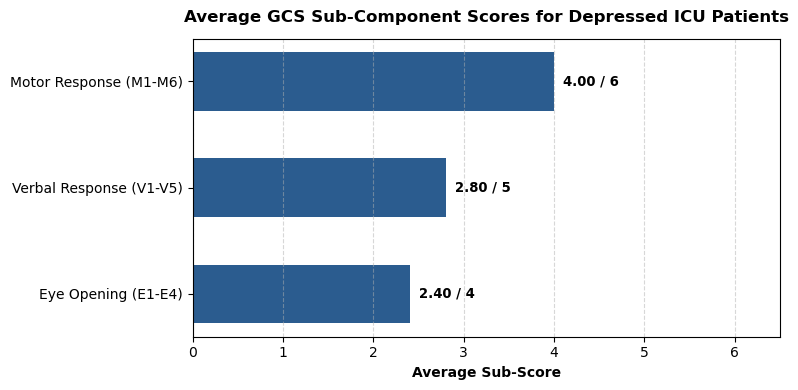

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# Calculate mean values for components
components_df = pd.DataFrame({
    'Component': ['Eye Opening (E1-E4)', 'Verbal Response (V1-V5)', 'Motor Response (M1-M6)'],
    'Mean Score': [
        icu_gcs_transfers['eye_opening'].mean(), 
        icu_gcs_transfers['verbal_response'].mean(), 
        icu_gcs_transfers['movement'].mean()
    ],
    'Max Possible': [4, 5, 6]
})

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(components_df['Component'], components_df['Mean Score'], color='#2b5c8f', height=0.55)

ax.set_xlabel('Average Sub-Score', fontsize=10, fontweight='bold')
ax.set_title('Average GCS Sub-Component Scores for Depressed ICU Patients', fontsize=12, fontweight='bold', pad=12)
ax.set_xlim(0, 6.5)
ax.grid(axis='x', linestyle='--', alpha=0.5)

for bar, max_val in zip(bars, components_df['Max Possible']):
    width = bar.get_width()
    ax.text(width + 0.1, bar.get_y() + bar.get_height()/2, f'{width:.2f} / {max_val}', 
            ha='left', va='center', fontweight='bold', fontsize=9.5)

plt.tight_layout()

plt.show()

### Key Insights
- Only **5 patients** had GCS < 15 and were in the ICU (admission ward or discharge department). All 5 were **admitted directly to the ICU** (3 were later discharged from Cardiology), so this describes who is placed in ICU rather than ward-to-ICU transfers.
- They span the whole severity range: profound coma (GCS 3: Eye 1, Verbal 1, Motor 1), moderate impairment (GCS 7: E2 V2 M3; GCS 11: E3 V3 M5, two patients) and mild impairment (GCS 14: E3 V5 M6).
- **Eye opening was reduced in all 5 patients** (score 1–3 out of 4), while verbal and motor scores were normal in the mildest case. The chart shows average sub-scores of **2.4 / 4 (eye), 2.8 / 5 (verbal) and 4.0 / 6 (motor)**.
- The two most severe patients (GCS 3 and 7) combined a **motor score ≤ 3 with a verbal score ≤ 2**, the pattern that signals loss of airway protection.
- **Caveat:** with only 5 patients this is descriptive and hypothesis-generating. It is supported by Question 4 (29.8% 6-month mortality when GCS < 15) and Question 12.

### Prescriptive Action to be taken
- **Automated escalation rule:** an electronic health record (EHR) alert when **GCS < 12 OR movement ≤ 3** in any ward heart-failure patient → immediate ICU/CCU review and rapid-response-team airway assessment.
- **GCS ≤ 8** → treat as a threatened airway: immediate ICU admission.
- **GCS 12–14 with eye opening ≤ 3** → urgent senior review and hourly neurological observations (see Questions 4 and 12).
- Validate these thresholds on a larger group of patients before making them mandatory.

## 2. Among patients with the "Both" (biventricular) heart failure type, does adding kidney function markers (creatinine, glomerular_filtration_rate) sharpen risk stratification — should nephrology co-management be triggered when both cardiac and renal markers are abnormal together (the "cardio-renal" pattern)?
### Reasoning
Biventricular ("Both") heart failure exacerbates venous congestion and arterial hypoperfusion, directly impairing renal perfusion (Cardiorenal Syndrome). Stratifying this subset by dual cardiac and renal dysfunction identifies high-mortality cohorts needing immediate joint care.

### Metrics, Biomarkers and Features used
Cardiac Dysfunction: heart_failure_type == 'Both', severe_hf (1 = Severe, 0 = Non-severe).Renal Function Biomarkers: creatinine (threshold $> 133\ \mu\text{mol/L}$, ≈ 1.5 mg/dL), glomerular_filtration_rate (eGFR $< 60\text{ mL/min/1.73m}^2$).Outcomes Tracked: death_6m (6-month mortality), readmission_6m (6-month readmission).
### Why used
Creatinine and eGFR quantify acute and chronic nephron strain. Combining them with severe HF markers tests whether renal impairment acts as an independent risk multiplier in biventricular failure.

In [4]:
import pandas as pd

wide = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")

# Filter to "Both" (biventricular) heart failure type only
both = wide[wide['heart_failure_type'] == 'Both'].copy()
print("N patients with 'Both' HF type:", len(both))

# Define abnormal renal function (standard clinical thresholds)
both['renal_abnormal'] = (both['creatinine'] > 133) | (both['glomerular_filtration_rate'] < 60)

# 4-way cardio-renal risk stratification
both['risk_group'] = both.apply(
    lambda r: (
        'Cardiac+Renal Both Abnormal' if r['severe_hf'] == 1 and r['renal_abnormal']
        else 'Cardiac Only Abnormal' if r['severe_hf'] == 1
        else 'Renal Only Abnormal' if r['renal_abnormal']
        else 'Neither Abnormal'
    ),
    axis=1
)

print("=== 4-Way Cardio-Renal Risk Stratification ===")
risk_group_outcomes = both.groupby('risk_group')[['death_6m', 'readmission_6m']].agg(['mean', 'count'])
print(risk_group_outcomes)

N patients with 'Both' HF type: 1480
=== 4-Way Cardio-Renal Risk Stratification ===
                             death_6m       readmission_6m      
                                 mean count           mean count
risk_group                                                      
Cardiac Only Abnormal        0.035714   140       0.385714   140
Cardiac+Renal Both Abnormal  0.141892   148       0.439189   148
Neither Abnormal             0.013616   661       0.363086   661
Renal Only Abnormal          0.020716   531       0.500942   531


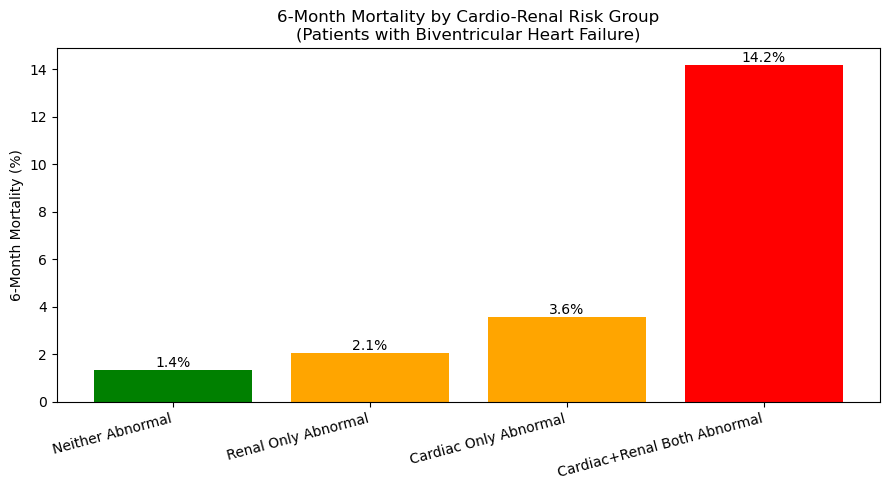

In [5]:
import matplotlib.pyplot as plt

order = ['Neither Abnormal', 'Renal Only Abnormal', 'Cardiac Only Abnormal', 'Cardiac+Renal Both Abnormal']
mortality_pct = (both.groupby('risk_group')['death_6m'].mean() * 100).reindex(order)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(order, mortality_pct.values, color=['green', 'orange', 'orange', 'red'])
ax.bar_label(bars, fmt='%.1f%%', fontsize=10)

plt.title("6-Month Mortality by Cardio-Renal Risk Group\n(Patients with Biventricular Heart Failure)")
plt.ylabel("6-Month Mortality (%)")
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

### Key Insights
**6-Month Mortality**: The "Cardiac+Renal Both Abnormal" group has a **14.19%** 6-month mortality ($n=148$), compared with 3.57% for Cardiac Only Abnormal ($n=140$), 2.07% for Renal Only Abnormal ($n=531$) and 1.36% for Neither Abnormal ($n=661$). Dual abnormality carries about **4× the mortality of cardiac impairment alone** and more than **10× that of patients with neither**.

**6-Month Readmission**: Kidney impairment drives readmission regardless of cardiac severity — Renal Only **50.09%** and Cardiac+Renal 43.92%, vs 38.57% for Cardiac Only and 36.31% for Neither.

### Prescriptive Action to be taken
- **Mandatory Nephrology Co-Management Protocol:** automatically trigger an inpatient nephrology consultation for any patient with biventricular heart failure (heart_failure_type = 'Both') when severe_hf = 1 AND either creatinine $> 133\ \mu$mol/L or eGFR $< 60$.
- **Treatment plan:** optimise loop diuretics with renal-sparing protocols, avoid nephrotoxic agents, and schedule a 14-day post-discharge cardio-renal follow-up.
- **Renal-only abnormal patients** (the highest readmission group, 50.1%) → readmission-prevention follow-up with repeat kidney tests within 1–2 weeks (see Question 16).

## 3. Do patients with severe heart failure (severe_hf flag) combined with elevated pulmonary pressure (pulmonary_pressure) show a distinct readmission pattern that would justify pre-discharge pulmonary pressure monitoring as a standard check before sending patients home?
### Reasoning
Severe heart failure combined with elevated pulmonary artery systolic pressure (PASP $> 35\text{ mmHg}$) reflects right ventricular strain and persistent backward hemodynamic congestion. However, because pulmonary_pressure is recorded in only $9.06\%$ of patients ($182/2008$), universal pre-discharge pulmonary pressure monitoring lacks statistical backing to lower readmission rates ($33.3\%$ vs. $38.5\%$ for the whole cohort) and is hindered by severe data sparsity.
### Metrics Biomarkers and Features used
Biomarkers & Clinical Flags: pulmonary_pressure (echo-estimated PASP cutoff $> 35\text{ mmHg}$) and severe_hf binary flag ($1$ = Severe, $0$ = Non-severe).Risk Stratification Groups: Severe HF + Elevated PP ($n=15$), Severe HF Only ($n=28$), Elevated PP Only ($n=66$), and Neither ($n=73$).Outcome Metrics: readmission_6m and death_6m mean rates per subgroup across the $N=182$ cohort.
### Why used
PASP Threshold ($> 35\text{ mmHg}$): Uses the standard clinical echocardiographic threshold for pulmonary hypertension to identify right-sided hemodynamic overload.Coverage Analysis: Evaluating data coverage ($182/2008$ patients) tests whether pulmonary pressure monitoring is broadly feasible or restricted to high-acuity diagnostic sub-populations.4-Way Stratification: Isolates whether elevated pulmonary pressure acts as an independent readmission driver in severe heart failure patients.

In [6]:
import pandas as pd

wide = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")

# Only patients with pulmonary_pressure recorded (this is a sparse measurement — check coverage first)
sub = wide[wide['pulmonary_pressure'].notna()].copy()
print("N patients with pulmonary_pressure recorded:", len(sub), "out of", len(wide))

# Elevated pulmonary pressure — standard echo-estimated threshold for pulmonary hypertension (PASP > 35 mmHg)
sub['elevated_pp'] = sub['pulmonary_pressure'] > 35

sub['risk_group'] = sub.apply(
    lambda r: (
        'Severe HF + Elevated PP' if r['severe_hf'] == 1 and r['elevated_pp']
        else 'Severe HF Only' if r['severe_hf'] == 1
        else 'Elevated PP Only' if r['elevated_pp']
        else 'Neither'
    ),
    axis=1
)

print("=== 6-Month Outcomes by Severe HF + Pulmonary Pressure Group ===")
outcomes = sub.groupby('risk_group')[['readmission_6m', 'death_6m']].agg(['mean', 'count'])
print(outcomes)

N patients with pulmonary_pressure recorded: 182 out of 2008
=== 6-Month Outcomes by Severe HF + Pulmonary Pressure Group ===
                        readmission_6m        death_6m      
                                  mean count      mean count
risk_group                                                  
Elevated PP Only              0.363636    66  0.075758    66
Neither                       0.383562    73  0.054795    73
Severe HF + Elevated PP       0.333333    15  0.000000    15
Severe HF Only                0.392857    28  0.071429    28


### Key Insights
**No Readmission Spike**: Patients with Severe HF + Elevated PP show a lower 6-month readmission rate ($33.33\%$) than Severe HF Only ($39.29\%$), Elevated PP Only ($36.36\%$), and Neither ($38.36\%$).

**Data Sparsity Limit**: Pulmonary pressure is captured in only $9.1\%$ of total cases, making universal pre-discharge screening resource-inefficient and non-predictive for general readmission reduction.

**Mortality Observations**: Zero deaths ($0.0\%$) were recorded in the small Severe HF + Elevated PP group ($n=15$), compared to $7.14\%$ in Severe HF Only and $7.58\%$ in Elevated PP Only, reflecting small-sample distortion rather than true clinical protection.

### Prescriptive Action to be taken
**Reject Universal Screening**: Do not mandate routine pre-discharge pulmonary pressure/echocardiographic monitoring for all patients prior to home discharge, as it does not justify the cost or operational delay.

**Selective Hemodynamic Monitoring**: Reserve invasive (e.g., CardioMEMS) or echocardiographic pulmonary pressure checks exclusively for refractory heart failure patients with recurrent unexplained decompensations.

**Focus on Standard Decongestion**: Prioritize standardized clinical decongestion protocols (e.g., 24-hour weight stability, oral diuretic transition, and BNP trend analysis) over isolated pulmonary pressure measurements to prevent 6-month readmissions.

## 4. Among patients with impaired consciousness at admission, which specific GCS component (eye_opening, verbal_response, or movement) combined with abnormal liver function (total_bilirubin, ALP) most strongly predicts poor outcome — is hepatic encephalopathy an under-recognized driver of "confusion" in this cohort?

### Reasoning
Confusion or drowsiness in a heart-failure patient is usually blamed on low cardiac output and poor blood flow to the brain. But congestive (right-sided/biventricular) heart failure also congests the liver, and a failing liver can itself cause **hepatic encephalopathy** — a reversible cause of impaired consciousness that needs different treatment (e.g., lactulose, ammonia control) from cardiac escalation. By splitting the GCS into its three components and crossing each with liver function, we test (a) which neurological deficit carries the most prognostic weight and (b) whether abnormal liver function adds extra mortality on top of it — which would suggest hepatic encephalopathy is being missed.

### Metrics Biomarkers and Features used
- gcs — filter for impaired consciousness (GCS < 15, n = 57)
- eye_opening (depressed if < 4), verbal_response (depressed if < 5), movement (depressed if < 6)
- total_bilirubin (abnormal if > 34 µmol/L, ~2× upper limit) and ALP (abnormal if > 150 U/L) → combined into a liver_abnormal flag (13 patients abnormal; 52 of 57 had liver labs)
- death_6m — 6-month mortality (outcome)

### Why used
- **GCS components instead of the total score** — the same total GCS can hide very different deficits; a component-level view shows which bedside observation is the most useful early-warning signal.
- **total_bilirubin and ALP** — the routine liver markers available in the dataset; bilirubin reflects impaired excretion/congestion and ALP reflects congestive hepatopathy/cholestasis. Together they approximate "abnormal liver function" (ammonia, the direct hepatic-encephalopathy marker, is not recorded).
- **death_6m** — the most clinically important outcome, with enough events in this small subgroup (17 deaths among 57 patients) to compare groups.

In [7]:
import pandas as pd

wide = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")

# Filter to impaired consciousness patients (GCS < 15)
impaired = wide[wide['gcs'] < 15].copy()
print("N impaired consciousness patients (GCS < 15):", len(impaired))

# Flag whether each GCS component is below its maximum (i.e. "depressed")
impaired['eye_depressed'] = impaired['eye_opening'] < 4        # max eye score = 4
impaired['verbal_depressed'] = impaired['verbal_response'] < 5  # max verbal score = 5
impaired['movement_depressed'] = impaired['movement'] < 6       # max motor score = 6

# Abnormal liver function (bilirubin > 2x upper limit, or elevated ALP)
impaired['liver_abnormal'] = (impaired['total_bilirubin'] > 34) | (impaired['ALP'] > 150)
print("N with liver labs available:", impaired[['total_bilirubin', 'ALP']].notna().all(axis=1).sum())
print("N with abnormal liver function:", impaired['liver_abnormal'].sum())

# Check each GCS component combined with liver status, against 6-month mortality
for component in ['eye_depressed', 'verbal_depressed', 'movement_depressed']:
    print(f"\n=== {component} x liver_abnormal → 6-month mortality ===")
    result = impaired.groupby([component, 'liver_abnormal'])['death_6m'].agg(['mean', 'count'])
    print(result)

N impaired consciousness patients (GCS < 15): 57
N with liver labs available: 52
N with abnormal liver function: 13

=== eye_depressed x liver_abnormal → 6-month mortality ===
                                  mean  count
eye_depressed liver_abnormal                 
False         False           0.076923     13
              True            0.000000      2
True          False           0.387097     31
              True            0.363636     11

=== verbal_depressed x liver_abnormal → 6-month mortality ===
                                     mean  count
verbal_depressed liver_abnormal                 
False            False           0.181818     11
                 True            0.500000      2
True             False           0.333333     33
                 True            0.272727     11

=== movement_depressed x liver_abnormal → 6-month mortality ===
                                       mean  count
movement_depressed liver_abnormal                 
False              False

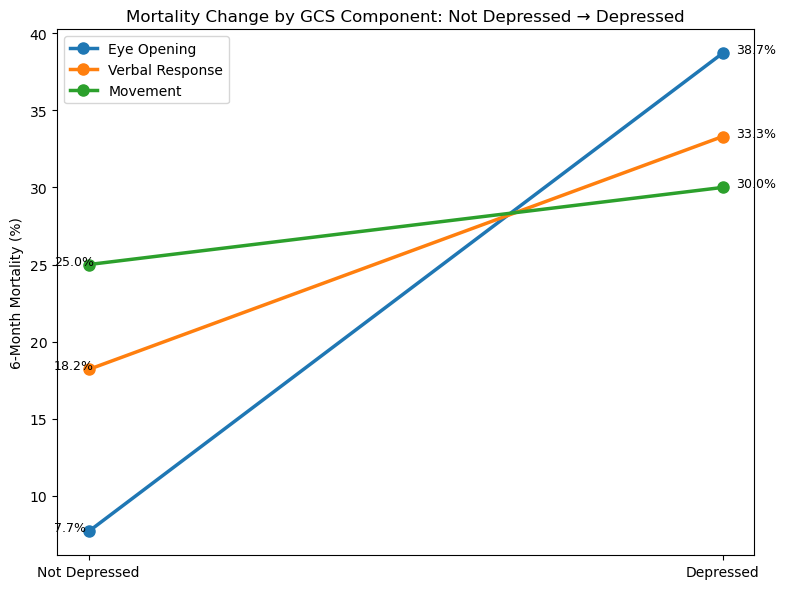

In [8]:
import matplotlib.pyplot as plt

components = {
    'Eye Opening': [7.7, 38.7],
    'Verbal Response': [18.2, 33.3],
    'Movement': [25.0, 30.0]
}

fig, ax = plt.subplots(figsize=(8, 6))

for label, values in components.items():
    ax.plot(['Not Depressed', 'Depressed'], values, marker='o', linewidth=2.5, markersize=8, label=label)
    # Label the endpoint values
    ax.annotate(f"{values[0]}%", (0, values[0]), textcoords="offset points", xytext=(-25, 0), fontsize=9)
    ax.annotate(f"{values[1]}%", (1, values[1]), textcoords="offset points", xytext=(10, 0), fontsize=9)

ax.set_ylabel("6-Month Mortality (%)")
ax.set_title("Mortality Change by GCS Component: Not Depressed → Depressed")
ax.legend()
plt.tight_layout()
plt.show()

### Key Insights
- **Impaired consciousness is a very high-risk state:** 17 of the 57 patients with GCS < 15 (29.8%) died within 6 months — roughly 10× the whole-cohort 6-month mortality (~2.8%).
- **Eye opening is the strongest single component.** In patients with normal liver function, mortality jumps from **7.7% → 38.7%** when eye opening is depressed (≈5×), compared with 18.2% → 33.3% for verbal response (≈1.8×) and 25.0% → 30.0% for movement (the "not depressed" movement group has only 4 patients, so that comparison is unreliable). The chart shows eye opening has by far the steepest line.
- **Abnormal liver function does not add risk.** Within each depressed component, mortality is similar or lower when liver tests are abnormal: eye 36.4% vs 38.7%, verbal 27.3% vs 33.3%, movement 33.3% vs 30.0%. There is no consistent extra mortality from the liver, so hepatic encephalopathy does **not** appear to be an under-recognised driver of fatal "confusion" in this cohort — impaired consciousness here looks mainly cardiac/hypoperfusion-driven.
- **Caveat:** the subgroups are very small (only 13 with abnormal liver function; some cells have n = 2–4) and ammonia is not available, so these findings are hypothesis-generating.

### Prescriptive Action to be taken
- **Use eye opening as the priority bedside trigger:** any HF patient with eye_opening ≤ 3 (opens eyes only to voice, pain, or not at all) should get an urgent senior medical review and be considered for CCU/ICU escalation, alongside the GCS < 12 / movement ≤ 3 rule from Question 1.
- **Treat any GCS < 15 as a high-mortality marker:** closer neurological and vital-sign monitoring, early goals-of-care discussion, and caregiver involvement.
- **Do not routinely label confusion as hepatic encephalopathy.** Check bilirubin and ALP as part of the standard work-up, but order ammonia and start encephalopathy treatment only when liver tests are abnormal **and** there are clinical signs (e.g., asterixis, known cirrhosis).
- Record ammonia and collect a larger sample before drawing a final conclusion on the liver–consciousness link.

## 5. What combination of admission-day vitals (pulse, respiration, SBP, DBP) and lab values is associated with safe early discharge (low discharge_day) without increased 28-day readmission risk?

### Reasoning
Bed pressure pushes hospitals towards shorter stays, but sending patients home too early risks a bounce-back within 28 days. If admission-day vitals and routine labs can tell apart patients who go home early **and stay well** from those who go home early **and come back**, clinicians gain an objective day-one checklist for planning early discharge safely. We split patients by length of stay (≤ 7 days, just below the median of 8) and 28-day readmission, then compared their admission-day values.

### Metrics Biomarkers and Features used
- discharge_day → short_stay flag (≤ 7 days)
- readmission_28d — 28-day readmission (outcome)
- Derived 4 groups: Safe Early Discharge (n = 902), Risky Early Discharge (n = 63), Long Stay No Readmit (n = 966), Long Stay Readmitted (n = 77)
- Admission vitals: pulse, resp (respiration rate), sbp, dbp
- Admission labs: creatinine, sodium, hemoglobin, brain_natriuretic_peptide (BNP)

### Why used
- **discharge_day and readmission_28d** — define "safe early discharge" directly: a short stay with no 28-day bounce-back. 28 days is the standard quality window for judging premature discharge.
- **Vitals (pulse, resp, SBP, DBP)** — recorded for every patient on arrival and reflect haemodynamic stability.
- **creatinine** — kidney function; cardio-renal strain slows safe decongestion.
- **sodium** — low sodium signals neurohormonal activation and diuretic resistance.
- **hemoglobin** — anaemia worsens heart-failure symptoms and recovery.
- **BNP** — direct marker of cardiac wall stress and congestion severity.

In [9]:
import pandas as pd

wide = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")

# Define "short stay" as ≤7 days (just below the median of 8)
wide['short_stay'] = wide['discharge_day'] <= 7

wide['group'] = wide.apply(
    lambda r: (
        'Safe Early Discharge' if r['short_stay'] and r['readmission_28d'] == 0
        else 'Risky Early Discharge' if r['short_stay'] and r['readmission_28d'] == 1
        else 'Long Stay, No Readmit' if not r['short_stay'] and r['readmission_28d'] == 0
        else 'Long Stay, Readmitted'
    ),
    axis=1
)

print(wide['group'].value_counts())

# Compare admission-day vitals and key labs across the 4 groups
vitals_labs = ['pulse', 'resp', 'sbp', 'dbp', 'creatinine', 'sodium', 'hemoglobin', 'brain_natriuretic_peptide']
comparison = wide.groupby('group')[vitals_labs].mean().round(1)
print(comparison.T)

group
Long Stay, No Readmit    966
Safe Early Discharge     902
Long Stay, Readmitted     77
Risky Early Discharge     63
Name: count, dtype: int64
group                      Long Stay, No Readmit  Long Stay, Readmitted  \
pulse                                       84.9                   83.4   
resp                                        19.1                   19.1   
sbp                                        130.5                  124.6   
dbp                                         75.7                   74.2   
creatinine                                 112.9                  130.3   
sodium                                     137.8                  135.8   
hemoglobin                                 114.4                  113.8   
brain_natriuretic_peptide                 1362.6                 1513.6   

group                      Risky Early Discharge  Safe Early Discharge  
pulse                                       85.8                  85.8  
resp                          

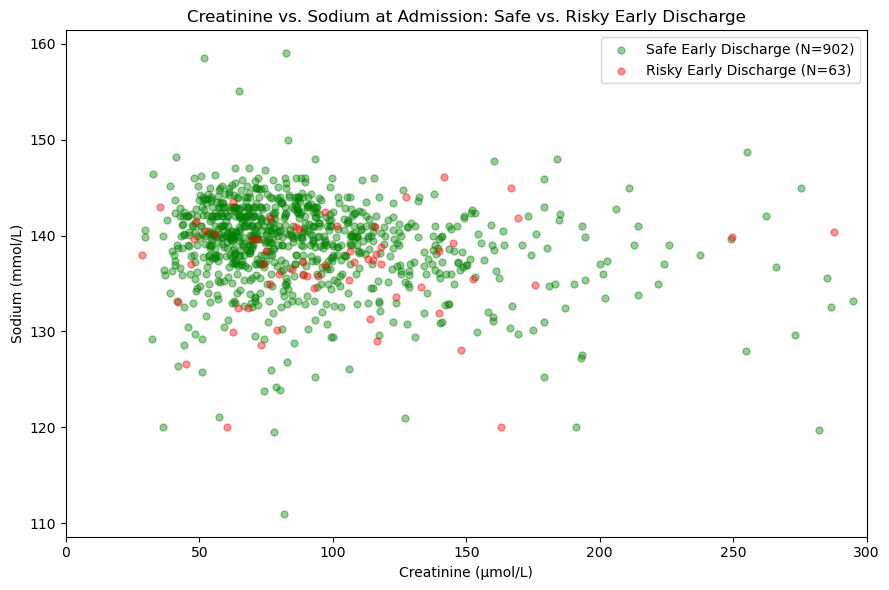

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 6))

for group, color in [('Safe Early Discharge', 'green'), ('Risky Early Discharge', 'red')]:
    sub = wide[wide['group'] == group]
    ax.scatter(sub['creatinine'], sub['sodium'], alpha=0.4, s=25, color=color, label=f"{group} (N={len(sub)})")

ax.set_xlabel("Creatinine (µmol/L)")
ax.set_ylabel("Sodium (mmol/L)")
ax.set_title("Creatinine vs. Sodium at Admission: Safe vs. Risky Early Discharge")
ax.set_xlim(0, 300)  # zoom in, since a few extreme creatinine outliers exist
ax.legend()
plt.tight_layout()
plt.show()

### Key Insights
- **Early discharge is usually safe:** 902 of 965 short-stay patients (93.5%) were not readmitted within 28 days; the short-stay readmission rate (6.5%) is no higher than for long stays (77 of 1,043, 7.4%).
- **Vitals do not separate safe from risky early discharge:** pulse (85.8 vs 85.8), respiration (19.0 vs 19.1) and DBP (77.9 vs 78.0) are identical; SBP is only slightly higher in the safe group (132.8 vs 128.6 mmHg).
- **Labs do separate them.** Safe early discharges had **lower creatinine** (102.3 vs 114.7 µmol/L), **higher sodium** (139.0 vs 136.9 mmol/L) and **lower BNP** (1,159 vs 1,462) — i.e., better kidney function, no low sodium, and less congestion. Hemoglobin was the same (115.8 vs 116.0).
- **The same lab pattern marks readmission regardless of stay length:** the Long Stay, Readmitted group had the worst profile of all (creatinine 130.3, sodium 135.8, BNP 1,514, SBP 124.6). So readmission is driven by the patient's renal/congestion profile, not by the short stay itself.
- The creatinine-vs-sodium scatter shows the risky early discharges drifting towards higher creatinine and lower sodium, but with a lot of overlap — no single cut-off works alone, so the markers should be used together.

### Prescriptive Action to be taken
- **Create an admission-day "early discharge readiness" checklist** based on labs, not vitals: sodium ≥ ~138 mmol/L, creatinine near normal (≤ ~105 µmol/L), BNP below ~1,200, and SBP ≥ ~130 mmHg → eligible for a ≤ 7-day discharge pathway.
- **Do not fast-track** patients with sodium < ~137 mmol/L, creatinine > ~115 µmol/L or high BNP: confirm decongestion and stable kidney function with repeat labs before discharge, and book a follow-up visit with repeat labs within 7 days.
- Do not use normal vitals alone to justify early discharge.
- The thresholds above come from group averages in this cohort — validate them prospectively before making them hard rules.

## 6. Which patient profile — by admission type, department, and severity markers — carries high enough risk that they should be prioritized for closer/more intensive follow-up (regardless of method)?"

### Reasoning
Follow-up resources (nurse phone calls, early clinic slots, telemonitoring) are limited, so they should go to the patients most likely to be readmitted or die soon after discharge. Admission type, discharge department and heart-failure severity are all known before discharge and need no extra testing. We first checked each factor on its own, then combined the strongest ones to find a simple, usable profile for prioritising follow-up.

### Metrics Biomarkers and Features used
- admission_type (Emergency / NonEmergency)
- discharge_department (Cardiology, GeneralWard, ICU, Others)
- heart_failure_severity (2–4 scale; 4 = most severe)
- Derived high_risk_profile = Emergency admission **and** severity 4 (n = 304)
- Outcomes: readmission_28d, death_28d

### Why used
- **admission_type** — emergency arrivals are usually less stable and may be discharged with unresolved problems.
- **discharge_department** — tests whether where the patient was looked after changes early risk (a simple operational lever).
- **heart_failure_severity** — direct measure of disease severity at admission.
- **readmission_28d and death_28d** — the first 4 weeks after discharge is when follow-up (early review, medicine reconciliation) can make the most difference, and it is the standard quality-of-care window.

In [11]:
import pandas as pd

wide = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")

# --- Check each factor individually first ---
print("Readmission by admission_type:")
print((wide.groupby('admission_type')['readmission_28d'].mean() * 100).round(2))

print("\nReadmission by discharge_department:")
print((wide.groupby('discharge_department')['readmission_28d'].mean() * 100).round(2))

print("\nReadmission by heart_failure_severity (1-4 scale):")
print((wide.groupby('heart_failure_severity')['readmission_28d'].mean() * 100).round(2))

# --- Combined high-risk profile: Emergency admission + Severity level 4 ---
wide['high_risk_profile'] = (wide['admission_type'] == 'Emergency') & (wide['heart_failure_severity'] == 4)

print("\n=== High-Risk Profile (Emergency + Severity 4) vs Rest ===")
print("28-day readmission:")
print((wide.groupby('high_risk_profile')['readmission_28d'].agg(['mean', 'count'])).round(3))
print("28-day mortality:")
print((wide.groupby('high_risk_profile')['death_28d'].agg(['mean', 'count'])).round(3))

# --- Full severity x admission type grid ---
print("\n=== Readmission Rate: Severity x Admission Type ===")
grid = (pd.crosstab(wide['heart_failure_severity'], wide['admission_type'],
                     values=wide['readmission_28d'], aggfunc='mean') * 100).round(2)
print(grid)

Readmission by admission_type:
admission_type
Emergency       7.64
NonEmergency    6.37
Name: readmission_28d, dtype: float64

Readmission by discharge_department:
discharge_department
Cardiology     7.16
GeneralWard    5.81
ICU            0.00
Others         7.69
Name: readmission_28d, dtype: float64

Readmission by heart_failure_severity (1-4 scale):
heart_failure_severity
2    3.97
3    6.45
4    9.58
Name: readmission_28d, dtype: float64

=== High-Risk Profile (Emergency + Severity 4) vs Rest ===
28-day readmission:
                    mean  count
high_risk_profile              
False              0.063   1704
True               0.109    304
28-day mortality:
                    mean  count
high_risk_profile              
False              0.013   1704
True               0.049    304

=== Readmission Rate: Severity x Admission Type ===
admission_type          Emergency  NonEmergency
heart_failure_severity                         
2                            3.70          4.19
3  

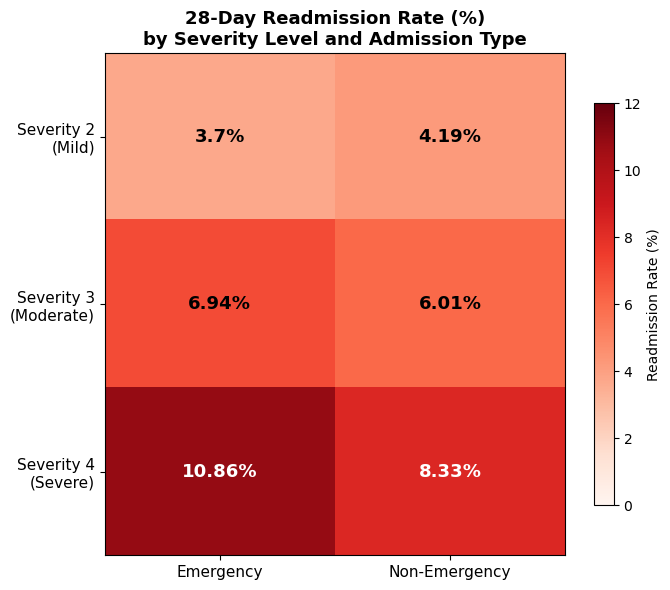

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# All values below are directly computed from wide_merged_table.csv — nothing estimated or fabricated
severity_labels = ['Severity 2\n(Mild)', 'Severity 3\n(Moderate)', 'Severity 4\n(Severe)']
admission_labels = ['Emergency', 'Non-Emergency']
readmission_grid = np.array([
    [3.70, 4.19],
    [6.94, 6.01],
    [10.86, 8.33]
])

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(readmission_grid, cmap='Reds', aspect='auto', vmin=0, vmax=12)

# Print the actual value inside each cell — no other markings
for i in range(readmission_grid.shape[0]):
    for j in range(readmission_grid.shape[1]):
        text_color = 'white' if readmission_grid[i, j] > 7 else 'black'
        ax.text(j, i, f"{readmission_grid[i, j]}%", ha='center', va='center',
                fontsize=13, fontweight='bold', color=text_color)

ax.set_xticks(range(len(admission_labels)))
ax.set_xticklabels(admission_labels, fontsize=11)
ax.set_yticks(range(len(severity_labels)))
ax.set_yticklabels(severity_labels, fontsize=11)
ax.set_title("28-Day Readmission Rate (%)\nby Severity Level and Admission Type", fontsize=13, fontweight='bold')

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Readmission Rate (%)")

plt.tight_layout()

plt.show()

### Key Insights
- **Severity is the strongest single driver:** 28-day readmission rises from **3.97%** (severity 2) → **6.45%** (severity 3) → **9.58%** (severity 4), a 2.4× gradient.
- **Admission type alone has a small effect** (Emergency 7.64% vs NonEmergency 6.37%), and **department makes little difference** (Cardiology 7.16%, GeneralWard 5.81%, Others 7.69%; ICU 0% but only 12 patients).
- **The combined profile identifies the highest-risk group:** Emergency + Severity 4 patients (n = 304, ~15% of the cohort) had **10.9%** 28-day readmission vs 6.3% for everyone else (≈1.7×) and **4.9%** 28-day mortality vs 1.3% (≈3.8×).
- **Heatmap:** the darkest cell is Severity 4 + Emergency (10.86%); Severity 4 + Non-Emergency (8.33%) is still higher than any severity 2–3 cell. At severity 2–3, admission type makes almost no difference (3.70% vs 4.19%; 6.94% vs 6.01%).

### Prescriptive Action to be taken
- **Tier 1 – Emergency + Severity 4:** highest follow-up priority — phone call within 72 hours, clinic review within 7 days, medicine reconciliation, and telemonitoring/early-warning plan for the first month.
- **Tier 2 – Severity 4 (non-emergency) or Emergency + Severity 3:** clinic review within 14 days plus a nurse call in week 1.
- **Tier 3 – Severity 2–3 planned admissions:** standard follow-up.
- **Do not allocate follow-up by department** — severity and admission route matter far more than which ward discharged the patient.

In [13]:
import pandas as pd

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")


## 7. Which medication combination should be prescribed to maximize 6-month survival?
### Reasoning

Heart-failure patients often receive multiple medications simultaneously. Instead of analyzing individual drugs alone, medication combinations were evaluated to identify treatment patterns associated with improved 6-month survival. Using survival outcomes helps determine which therapies may contribute to better long-term clinical results.

### Metrics, Biomarkers and Features Used
- 25 drug flag columns (`drug_*`, 1 = prescribed), built from the prescriptions table; the **10 most-prescribed drugs** are used to label each patient's medication combination
- `medication_combination` (derived) — only combinations with **≥ 10 patients** are kept
- `death_6m` → 6-month survival rate for each combination
- Random Forest feature importance of the 25 drug flags for predicting `death_6m`

### Why These Were Used
- **Drug flags** are the only treatment information in the dataset, and patients receive several drugs together, so combinations are more realistic than single drugs.
- **Top 10 drugs and ≥ 10 patients per combination** keep the analysis to common, interpretable regimens; rates from rarer combinations would be unreliable.
- **death_6m** is the outcome the question asks about (survival).
- **Random Forest importance** ranks which drugs carry the most information about death. It does **not** show direction — a drug can rank high because it is given to the sickest patients.

In [14]:
# Step 1 - Get Medication column

med_cols = [col for col in df.columns if col.startswith('drug_')]

print(f"Total medications: {len(med_cols)}")

Total medications: 25


In [15]:
# Step 2 - select most common medication

med_freq = df[med_cols].sum().sort_values(
    ascending=False
)

top_medications = med_freq.head(10).index.tolist()

print(top_medications)

['drug_Spironolactone_Tablet', 'drug_Furosemide_Injection', 'drug_Furosemide_Tablet', 'drug_Meglumine_Adenosine_Cyclophosphate_For_Injection', 'drug_Deslanoside_Injection', 'drug_Digoxin_Tablet', 'drug_Aspirin_Enteric-Coated_Tablet', 'drug_Atorvastatin_Calcium_Tablet', 'drug_Milrinone_Injection', 'drug_Sulfotanshinone_Sodium_Injection']


In [16]:
# Step 3 - create medication combination label

survival_df = df.copy()

survival_df['medication_combination'] = (
    survival_df[top_medications]
    .apply(
        lambda row: ', '.join(
            [
                col.replace('drug_', '')
                for col in top_medications
                if row[col] == 1
            ]
        ),
        axis=1
    )
)

survival_df['medication_combination'] = (
    survival_df['medication_combination']
    .replace('', 'No_Medication')
)

In [17]:
# Step 4 - Calculate survival rate

med_survival = (
    survival_df.groupby(
        'medication_combination'
    )
    .agg(
        Patients=('patient_id', 'count'),
        Deaths=('death_6m', 'sum')
    )
)

med_survival = med_survival[
    med_survival['Patients'] >= 10
]

med_survival['Survival_Rate'] = (
    (
        med_survival['Patients']
        -
        med_survival['Deaths']
    )
    /
    med_survival['Patients']
    * 100
)

med_survival = (
    med_survival
    .sort_values(
        'Survival_Rate',
        ascending=False
    )
)

print(
    med_survival.head(20)
)

                                                    Patients  Deaths  \
medication_combination                                                 
Spironolactone_Tablet                                     10       0   
Spironolactone_Tablet, Furosemide_Injection, Fu...        34       0   
Spironolactone_Tablet, Furosemide_Injection, Fu...        25       0   
Spironolactone_Tablet, Furosemide_Injection, Fu...        25       0   
Spironolactone_Tablet, Furosemide_Injection, Fu...        12       0   
Spironolactone_Tablet, Furosemide_Injection, Fu...        15       0   
Spironolactone_Tablet, Furosemide_Injection, Fu...        17       0   
Spironolactone_Tablet, Furosemide_Injection, Fu...        12       0   
Spironolactone_Tablet, Furosemide_Injection, Fu...        49       0   
Spironolactone_Tablet, Furosemide_Injection, Fu...        29       0   
Spironolactone_Tablet, Furosemide_Injection, Fu...        12       0   
Spironolactone_Tablet, Furosemide_Injection, Fu...        13    

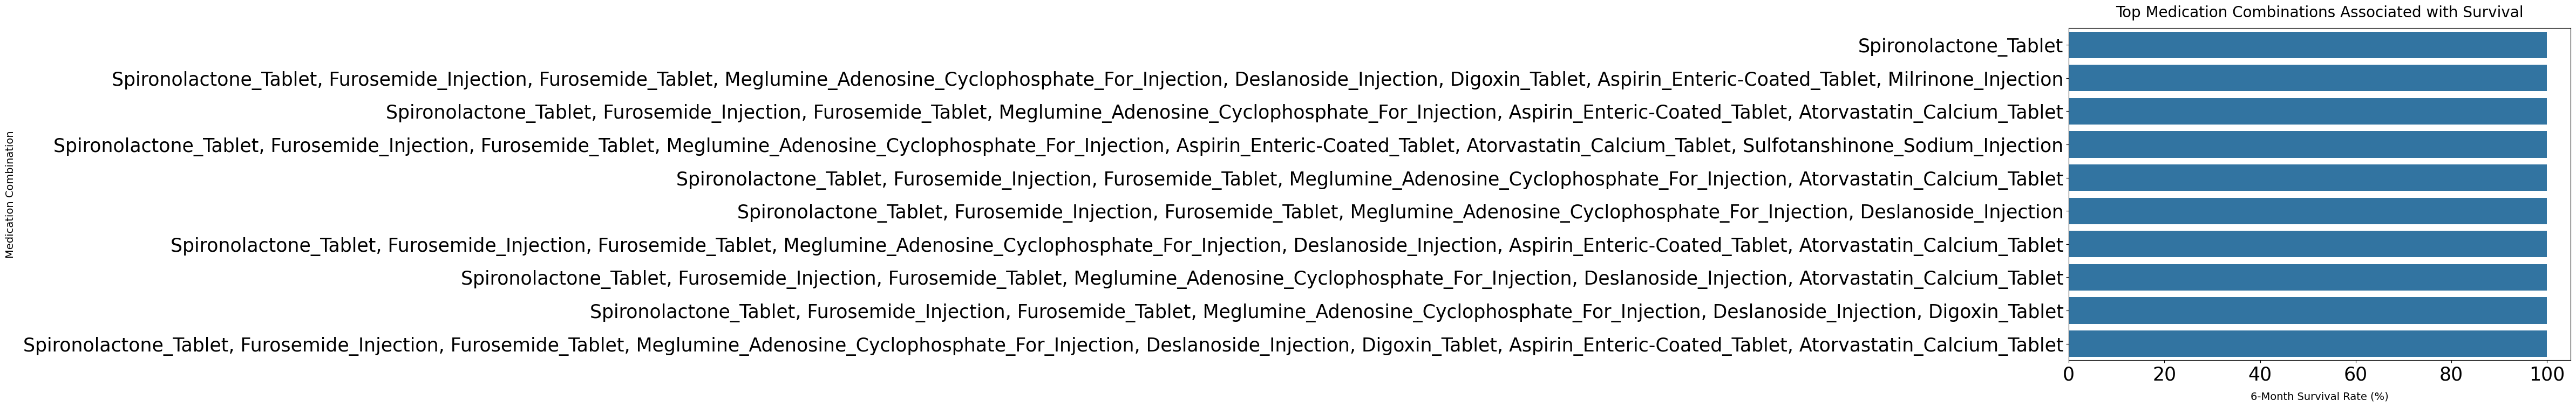

In [18]:
# Top surviver medication combination chart
import seaborn as sns
import matplotlib.pyplot as plt

top10 = med_survival.head(10)
plt.figure(figsize=(12,8))

sns.barplot(
    data=top10,
    x='Survival_Rate',
    y=top10.index
)

# Increase title size
plt.title(
    "Top Medication Combinations Associated with Survival", 
    fontsize=20, 
    pad=15  # Adds space between title and chart
)

# Increase X and Y axis label sizes
plt.xlabel("6-Month Survival Rate (%)", fontsize=14, labelpad=10)
plt.ylabel("Medication Combination", fontsize=14, labelpad=10)

# Increase the size of the tick numbers/labels on both axes
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)

plt.show()


In [19]:
# to determine which medications contribute most to survival.
from sklearn.ensemble import RandomForestClassifier

X = df[med_cols]

y = df['death_6m']

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X, y)

importance_df = pd.DataFrame({
    'Medication': med_cols,
    'Importance': rf.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        'Importance',
        ascending=False
    )
)

print(
    importance_df.head(15)
)

                                           Medication  Importance
17                           drug_Milrinone_Injection    0.064254
4                          drug_Deslanoside_Injection    0.063093
14  drug_Meglumine_Adenosine_Cyclophosphate_For_In...    0.059777
19                              drug_Shenfu_Injection    0.058861
0                  drug_Aspirin_Enteric-Coated_Tablet    0.058760
9                              drug_Furosemide_Tablet    0.054584
10                      drug_Heparin_Sodium_Injection    0.053228
1                    drug_Atorvastatin_Calcium_Tablet    0.050215
22                             drug_Torasemide_Tablet    0.047439
11                    drug_Hydrochlorothiazide_Tablet    0.044365
5                                 drug_Digoxin_Tablet    0.043221
3           drug_Clopidogrel_Hydrogen_Sulphate_Tablet    0.037965
18                       drug_Nitroglycerin_Injection    0.036505
20                         drug_Spironolactone_Tablet    0.035978
21        

### Key Insights
- **25 different drugs** were prescribed. The 10 most common were spironolactone, IV furosemide, oral furosemide, meglumine adenosine cyclophosphate, deslanoside, digoxin, aspirin, atorvastatin, milrinone and sulfotanshinone.
- **All 20 top combinations (≥ 10 patients each) had 100% 6-month survival, and every one contains spironolactone**, usually together with furosemide (injection and/or tablet). Spironolactone + a loop diuretic is the common backbone of the survivors' regimens.
- **These combinations are small (10–49 patients)** and overall 6-month mortality is only ~2.8%, so zero deaths in a group of this size can easily happen by chance. The data cannot prove that any single combination is best.
- **Random Forest ranking:** milrinone (0.064), deslanoside (0.063), meglumine adenosine cyclophosphate (0.060), Shenfu (0.059) and aspirin (0.059) are the most informative drugs. Milrinone and deslanoside are IV drugs used for decompensated, low-output heart failure, so they most likely **mark sicker patients** (confounding by indication) rather than cause death.
- All importance scores are low and close together (0.034–0.064), so **no single drug dominates** — medication alone explains little of 6-month mortality.
- Beta-blockers (e.g., metoprolol) and ACE inhibitors / ARBs (e.g., benazepril, valsartan) are **not among the 10 most-prescribed drugs**, so they could not be assessed in the combination analysis.

### Prescriptive Action to Be Taken
- Use **spironolactone + a loop diuretic** as the standard backbone for eligible patients, with potassium and kidney checks (see Questions 16 and 17).
- **Review full guideline-directed medical therapy (GDMT)** at discharge — beta-blocker and ACE inhibitor/ARB/ARNI use should be checked, since it appears low in this cohort.
- Treat the **need for IV inotropes (milrinone, deslanoside)** as a severity flag → ICU/CCU review during the stay and follow-up within 7 days of discharge.
- For high-risk patients (high CCI score, high BNP, elevated creatinine, severe HF): prioritise GDMT, structured post-discharge monitoring, adherence support, early follow-up and close kidney/cardiac biomarker monitoring.
- Do not choose prescriptions from this ranking alone — it is observational and needs an adjusted analysis before it is used to change practice.

## 8. Which Patient Groups Should Receive Stricter Medication Adherence Programs?

### Reasoning
Medication adherence is critical in heart-failure management. Patients with complex disease profiles, frequent hospital visits, multiple medications, and poor outcomes are more likely to miss doses or discontinue treatment. This analysis identifies groups that would benefit the most from enhanced adherence programs.

### Metrics, Biomarkers & Features Used
num_distinct_drugs
cci_score
readmission_6m
death_6m
visit_count
severe_hf
age_category

### Why These Were Used

These features identify patients who:

Have multiple chronic diseases.
Require many medications.
Have experienced repeated hospitalizations.
Show signs of severe heart failure.
Are already demonstrating poor outcomes.

Such patients are more vulnerable to poor adherence and treatment failure.

### Step 1: Identify High-Risk Groups by Readmission

In [20]:
adherence_risk = (
    df.groupby('readmission_6m')
      .agg(
          Avg_Drugs=('num_distinct_drugs', 'mean'),
          Avg_CCI=('cci_score', 'mean'),
          Avg_Visits=('visit_count', 'mean')
      )
)

print(adherence_risk)

                Avg_Drugs   Avg_CCI  Avg_Visits
readmission_6m                                 
0                7.485020  1.800325    1.076923
1                7.914618  1.959792    1.117723


### Step 2: Medication Burden vs Readmission

In [21]:
drug_burden = (
    df.groupby('num_distinct_drugs')
      ['readmission_6m']
      .mean()
      .mul(100)
      .reset_index()
)

drug_burden.columns = [
    'Number_of_Drugs',
    'Readmission_Rate'
]

print(drug_burden)

    Number_of_Drugs  Readmission_Rate
0               0.0        100.000000
1               1.0          0.000000
2               2.0         23.076923
3               3.0         27.777778
4               4.0         24.545455
5               5.0         31.521739
6               6.0         41.666667
7               7.0         38.410596
8               8.0         40.833333
9               9.0         41.992883
10             10.0         43.720930
11             11.0         37.068966
12             12.0         46.268657
13             13.0         45.833333
14             14.0         41.666667
15             15.0         16.666667
16             16.0          0.000000


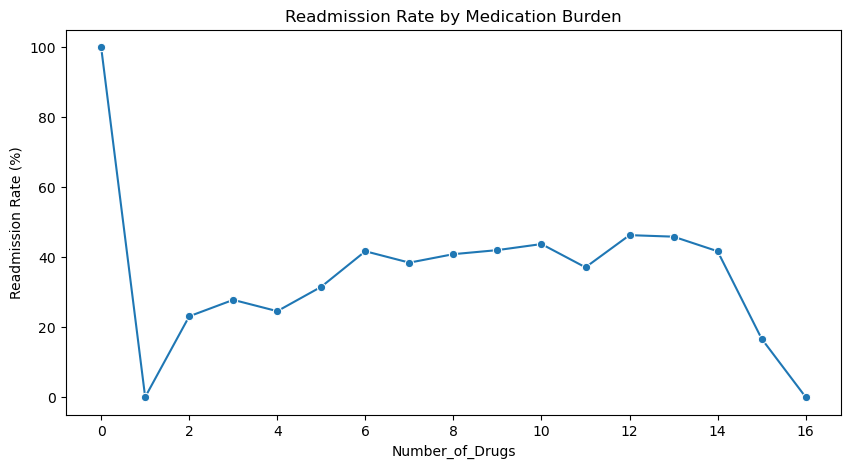

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.lineplot(
    data=drug_burden,
    x='Number_of_Drugs',
    y='Readmission_Rate',
    marker='o'
)

plt.title(
    'Readmission Rate by Medication Burden'
)

plt.ylabel('Readmission Rate (%)')

plt.show()

### Step 3: CCI Score vs Readmission

In [23]:
cci_readmission = (
    df.groupby('cci_score')
      ['readmission_6m']
      .mean()
      .mul(100)
      .reset_index()
)

print(cci_readmission)

   cci_score  readmission_6m
0        0.0       44.642857
1        1.0       34.935065
2        2.0       37.339056
3        3.0       42.119565
4        4.0       54.255319
5        5.0       60.000000
6        6.0      100.000000


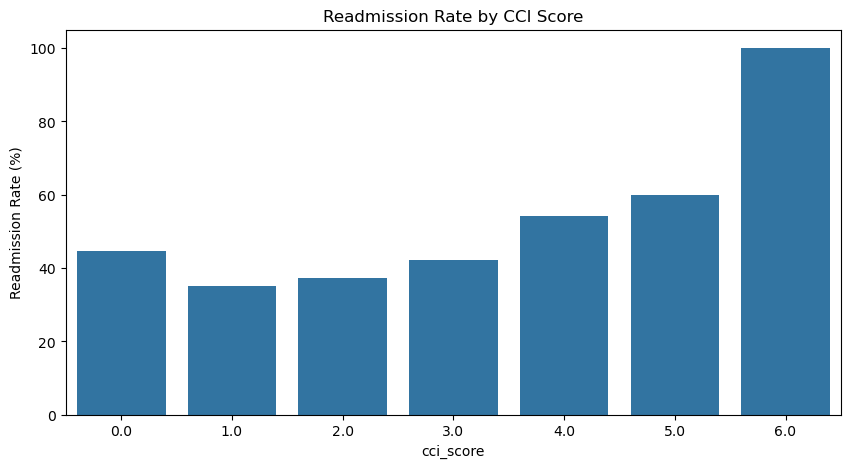

In [24]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=cci_readmission,
    x='cci_score',
    y='readmission_6m'
)

plt.title(
    'Readmission Rate by CCI Score'
)

plt.ylabel('Readmission Rate (%)')

plt.show()

### Step 4: Age Groups Needing Adherence Support

In [25]:
age_adherence = (
    df.groupby('age_category')
      .agg(
          Readmission_Rate=('readmission_6m',
                            lambda x: x.mean()*100),
          Avg_Drugs=('num_distinct_drugs',
                     'mean')
      )
      .reset_index()
)

print(age_adherence)

  age_category  Readmission_Rate  Avg_Drugs
0        21-29         75.000000   8.250000
1        29-39          8.333333   6.750000
2        39-49         32.142857   8.035714
3        49-59         37.735849   7.433962
4        59-69         35.326087   7.894022
5        69-79         41.258741   7.923077
6        79-89         37.770898   7.368421
7       89-110         41.584158   6.732673


### Step 5: Severe HF Patients

In [26]:
severe_hf_analysis = (
    df.groupby('severe_hf')
      .agg(
          Readmission_Rate=('readmission_6m',
                            lambda x: x.mean()*100),
          Mortality_Rate=('death_6m',
                          lambda x: x.mean()*100)
      )
)

print(severe_hf_analysis)

           Readmission_Rate  Mortality_Rate
severe_hf                                  
0                 38.409371        1.479655
1                 38.860104        8.549223


### Final Adherence Flag

In [27]:
df['Need_Adherence_Program'] = (
    (
        (df['num_distinct_drugs'] >= 8)
        |
        (df['cci_score'] >= 3)
        |
        (df['severe_hf'] == 1)
        |
        (df['visit_count'] >= 2)
    )
).astype(int)

df['Need_Adherence_Program'].value_counts()

Need_Adherence_Program
1    1436
0     572
Name: count, dtype: int64

### Key Insights
1. **Medication burden:** patients on ≤ 5 drugs were readmitted 23–32% of the time vs **37–46%** for those on 6–14 drugs; readmitted patients took more drugs on average (7.9 vs 7.5). (Groups with 0, 1, 15 or 16 drugs are too small to read.)
2. **Comorbidity (CCI):** readmission is 35–42% at CCI 1–3 but rises to **54.3% at CCI 4** and **60.0% at CCI 5**.
3. **Prior visits:** readmitted patients had slightly more previous visits (1.12 vs 1.08); patients with 3+ visits are readmitted 55% of the time (Question 10).
4. **Severe HF:** readmission is the same (38.9% vs 38.4%), but 6-month mortality is **8.5% vs 1.5% (≈ 6×)** — for these patients, adherence support is about preventing death.
5. **Age:** no age group stands out (35–42% readmission from age 39 up), so age is not a useful target.
6. **The current flag is too broad:** ≥ 8 drugs OR CCI ≥ 3 OR severe HF OR ≥ 2 visits marks **1,436 of 2,008 patients (71.5%)** — too many for an intensive programme.
7. The dataset has **no direct adherence measure**; these are proxies for complexity and risk.

### Prescriptive Action to Be Taken
- **Tier 1 – intensive adherence programme:** CCI ≥ 4, OR severe HF, OR (≥ 8 drugs AND ≥ 2 prior visits) → pharmacist medication review before discharge, follow-up call within 72 hours, blister packs/pill organisers, and telehealth monitoring.
- **Tier 2 – standard support:** ≥ 8 drugs only → medication reconciliation, simplify the regimen where possible, and reminders.
- For all tiers: medication reminders, pharmacist reviews and post-discharge follow-up calls.
- Start recording real adherence data (pharmacy refills, pill counts) to measure whether the programme works.

## 9. Which Interventions Would Most Reduce Mortality Among High-CCI Patients?

### Reasoning

Patients with a high Charlson Comorbidity Index (CCI) have multiple chronic conditions and are at substantially greater risk of mortality. The objective is to identify which interventions should be prioritized for these high-risk patients to improve survival outcomes. The analysis compares high-CCI patients (CCI ≥ 3) who died within 6 months with those who survived, using cardiac markers (ejection fraction, BNP), kidney function and medication burden.

### Metrics, Biomarkers & Features Used
Comorbidity Burden — cci_score (high CCI defined as ≥ 3)

Cardiac Severity — heart_pumping_efficiency, brain_natriuretic_peptide

Kidney Function — creatinine, glomerular_filtration_rate

Treatment Features — num_distinct_drugs

Outcome Variable (death_6m)

### Why These Were Used
CCI Score measures overall disease complexity.
Mortality (death_6m) is the primary outcome of interest.
heart_pumping_efficiency (ejection fraction) and BNP measure pump function and cardiac stress.
Renal biomarkers frequently drive poor outcomes in heart-failure populations.
Treatment variables help identify interventions that may improve survival.

### Step 1: Identify Mortality Risk Across CCI Groups

In [28]:
## Mortality by CCI Score

cci_mortality = (
    df.groupby('cci_score')
      ['death_6m']
      .mean()
      .mul(100)
      .reset_index()
)

cci_mortality.columns = [
    'CCI_Score',
    'Mortality_Rate'
]

print(cci_mortality)

   CCI_Score  Mortality_Rate
0        0.0       10.714286
1        1.0        1.948052
2        2.0        2.718169
3        3.0        2.717391
4        4.0        6.382979
5        5.0        6.666667
6        6.0        0.000000


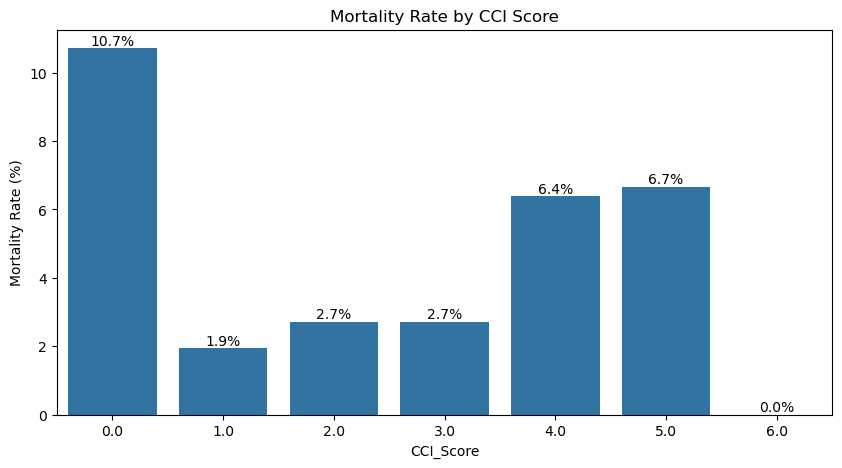

In [29]:
import seaborn as sns 
import matplotlib.pyplot as plt 

plt.figure(figsize=(10,5))

# 1. Assign the barplot to a variable (ax)
ax = sns.barplot(
    data=cci_mortality, 
    x='CCI_Score', 
    y='Mortality_Rate' 
)

# 2. Add labels on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')  # Formats to 1 decimal place with a % sign

plt.title('Mortality Rate by CCI Score') 
plt.ylabel('Mortality Rate (%)') 
plt.show()


### Step 2: Focus on High-CCI Patients

In [30]:
## Define High-Risk Group

high_cci = df[
    df['cci_score'] >= 3
]

In [31]:
## Compare Survivors vs Non-Survivors

high_cci.groupby('death_6m')[
    [
        'heart_pumping_efficiency',
        'brain_natriuretic_peptide',
        'creatinine',
        'glomerular_filtration_rate',
        'num_distinct_drugs'
    ]
].mean()

,heart_pumping_efficiency,brain_natriuretic_peptide,creatinine,glomerular_filtration_rate,num_distinct_drugs
death_6m,,,,,
0,51.116129,1389.612070,133.195405,55.957758,7.898048
1,57.250000,1957.802353,283.294118,30.631176,6.235294


### Key Insights
- **Mortality does not rise in a straight line with CCI:** 1.9–2.7% at CCI 1–3, then **6.4% at CCI 4** and **6.7% at CCI 5**. CCI 0 (10.7%) and CCI 6 (0%) are very small groups and unreliable. The real jump starts at **CCI ≥ 4**, not ≥ 3.
- **Kidney function is the biggest difference** between high-CCI patients who died and those who survived: creatinine **283 vs 133 µmol/L (≈ 2×)** and eGFR **30.6 vs 56.0** (stage G3b/G4 vs G3a).
- **BNP was higher in those who died** (1,958 vs 1,390, about 41% higher), showing more cardiac stress and congestion.
- **Ejection fraction was *not* lower in those who died** (57.3% vs 51.1%). Many high-CCI deaths happen with a preserved pump, so low EF should not be the only trigger for escalation.
- **Those who died received fewer drugs** (6.2 vs 7.9), which may reflect under-treatment or drugs withheld because of kidney failure — medication burden is not what drives death here.

### Prescriptive Actions to Be Taken
1. **Intensive follow-up programme** — if CCI ≥ 4 (or CCI 3 with another risk marker below): follow-up within 7 days of discharge and monthly monitoring for the first 6 months.
2. **Kidney-protection intervention** — if eGFR < 45 or creatinine > 133 µmol/L: nephrology referral, renal dose review of all medicines, avoid nephrotoxic drugs, and repeat kidney/potassium tests within 1–2 weeks (see Question 16).
3. **Heart-failure optimisation** — if BNP is high and/or severe_hf = 1, **whatever the ejection fraction**: optimise decongestion and heart-failure medicines, more frequent cardiac assessment, and specialist review.
4. **Medication review** — high-CCI patients on few drugs, especially with poor kidney function: pharmacist/cardiologist check that guideline therapy is not being withheld unnecessarily and that doses suit the kidney function.
5. **Remote monitoring** — high CCI + severe HF + previous readmission: telehealth follow-up, home symptom monitoring and early-warning alerts.

## 10. What Preventive Actions Should Be Taken for Patients With Repeated Admissions?
### Reasoning

Repeated admissions usually indicate unresolved clinical issues, poor disease management, medication non-adherence, severe heart failure progression, or inadequate follow-up care. Using variables such as visit_count, readmission_6m, cci_score, heart_failure_severity, num_distinct_drugs, and laboratory markers, we can identify patients most likely to be hospitalized again and recommend preventive actions.

### Metrics, Biomarkers & Features Used
Readmission Indicators — visit_count, readmission_6m

Disease Severity — heart_failure_severity, severe_hf, heart_pumping_efficiency, brain_natriuretic_peptide, creatinine

Comorbidity Burden — cci_score

Treatment Complexity — num_distinct_drugs

### Why These Were Used
visit_count and readmission_6m directly measure repeated hospital use, which is the target of the question — the 6-month readmission rate rises from 38.1% (1 visit) to 39.2% (2 visits) and 55.0% (3 visits).

heart_failure_severity, severe_hf and heart_pumping_efficiency describe how advanced the heart failure is; readmitted patients had a higher average severity score (3.22 vs 3.07).

brain_natriuretic_peptide and creatinine capture congestion and kidney strain — biomarkers that can be re-checked after discharge; readmitted patients had higher BNP (1,337 vs 1,246) and creatinine (114.3 vs 105.5).

cci_score reflects overall comorbidity burden (1.96 vs 1.80 in readmitted vs non-readmitted patients).

num_distinct_drugs reflects medication complexity, a common cause of non-adherence (7.9 vs 7.5 drugs).

Combining these into a simple flag / risk score (0–4) lets the team identify repeat-admission risk at discharge using data that is already collected.

### Step 1 - Identify Characteristics of Repeatedly Admitted Patients

In [32]:
## Compare Readmitted vs Non-Readmitted Patients

df.groupby('readmission_6m').agg({
    'visit_count': 'mean',
    'cci_score': 'mean',
    'heart_failure_severity': 'mean',
    'heart_pumping_efficiency': 'mean',
    'num_distinct_drugs': 'mean',
    'brain_natriuretic_peptide': 'mean',
    'creatinine': 'mean'
})

,visit_count,cci_score,heart_failure_severity,heart_pumping_efficiency,num_distinct_drugs,brain_natriuretic_peptide,creatinine
readmission_6m,,,,,,,
0,1.076923,1.800325,3.073684,50.854856,7.485020,1245.602547,105.521693
1,1.117723,1.959792,3.222510,50.425197,7.914618,1336.513770,114.295703


In [33]:
## Readmission Rate by Visit Frequency
readmission_visit = (
    df.groupby('visit_count')['readmission_6m']
      .mean()
      .mul(100)
      .reset_index()
)

print(readmission_visit)

   visit_count  readmission_6m
0            1       38.064516
1            2       39.166667
2            3       55.000000
3            4      100.000000
4            5       50.000000


### High-Risk Readmission Flag

In [34]:
df['high_readmission_risk'] = (
    (
        (df['visit_count'] >= 2)
        |
        (df['cci_score'] >= 3)
        |
        (df['severe_hf'] == 1)
        |
        (df['brain_natriuretic_peptide'] >
         df['brain_natriuretic_peptide'].median())
    )
).astype(int)

In [35]:
df['high_readmission_risk']
df['high_readmission_risk'].value_counts()



high_readmission_risk
1    1375
0     633
Name: count, dtype: int64

In [36]:
df[df['high_readmission_risk'] == 1].head()
(
    df['high_readmission_risk']
    .mean()
    * 100
)

np.float64(68.47609561752988)

In [37]:
df['readmission_risk_score'] = (
    (df['visit_count'] >= 2).astype(int)
    +
    (df['cci_score'] >= 3).astype(int)
    +
    (df['severe_hf'] == 1).astype(int)
    +
    (
        df['brain_natriuretic_peptide']
        >
        df['brain_natriuretic_peptide'].median()
    ).astype(int)
)

In [38]:
df['readmission_risk_score'].value_counts().sort_index()

readmission_risk_score
0    633
1    859
2    416
3     93
4      7
Name: count, dtype: int64

### Key Insights
- **Repeat visits raise readmission only from the 3rd visit:** 38.1% (1 visit), 39.2% (2 visits), **55.0% (3 visits)**. The 4- and 5-visit groups are too small to be reliable.
- **Readmitted patients look only slightly sicker** on each single marker: CCI 1.96 vs 1.80, severity 3.22 vs 3.07, drugs 7.9 vs 7.5, BNP 1,337 vs 1,246, creatinine 114.3 vs 105.5. Ejection fraction is the same (50.4% vs 50.9%). Because each difference is small, the markers need to be **combined**.
- **The "any one factor" flag is too broad:** visits ≥ 2 OR CCI ≥ 3 OR severe HF OR BNP above the median marks **1,375 of 2,008 patients (68.5%)**.
- **The 0–4 risk score is more usable:** 0 = 633, 1 = 859, 2 = 416, 3 = 93, 4 = 7 patients. A score of **≥ 2 selects 516 patients (25.7%)** and **≥ 3 selects 100 (5.0%)**, which are workable tiers.
- The notebook has not yet checked the readmission rate for each score level, so the score still needs to be validated.

### Prescriptive Actions to Be Taken
- **Score ≥ 3** → intensive pathway: follow-up within 7 days, telehealth/remote monitoring, pharmacist review, and BNP/creatinine re-check within 1–2 weeks.
- **Score 2** → follow-up within 14 days plus a nurse phone call in week 1.
- **Score 0–1** → standard follow-up.
- **3 or more prior visits** → assign a case manager and a personalised care plan (high CCI, severe HF).
- Before adopting the score, calculate the readmission rate at each score level to confirm it separates risk.

## 11. Which Age Groups Require Additional Post-Discharge Monitoring?

### Reasoning

Older patients often have higher comorbidity burden, lower physiological reserve, and greater risk of readmission or mortality after discharge. This analysis helps identify which age groups need closer follow-up and monitoring after leaving the hospital.

### Metrics, Biomarkers & Features Used
age_category

readmission_6m

death_6m

cci_score

### Why These Were Used
age_category is the grouping variable being tested — it decides which age bands would receive extra post-discharge monitoring.

readmission_6m and death_6m are the two outcomes that post-discharge monitoring aims to prevent, so each age band is checked on both.

cci_score tests whether older patients carry more disease burden — the average CCI rises steadily from 1.0 (21–29) to 2.04 (89–110) — which shows age partly acts as a proxy for comorbidity.

Note: the youngest bands (21–29, n = 4; 29–39, n = 12) are too small for reliable rates, so conclusions should focus on patients aged 39 and above.

In [39]:
## Readmission Rate by Age Group
age_readmission = (
    df.groupby('age_category')['readmission_6m']
      .mean()
      .mul(100)
      .reset_index()
)

print(age_readmission)


  age_category  readmission_6m
0        21-29       75.000000
1        29-39        8.333333
2        39-49       32.142857
3        49-59       37.735849
4        59-69       35.326087
5        69-79       41.258741
6        79-89       37.770898
7       89-110       41.584158


In [40]:
## Mortality Rate by Age Group

age_mortality = (
    df.groupby('age_category')['death_6m']
      .mean()
      .mul(100)
      .reset_index()
)

print(age_mortality)

  age_category  death_6m
0        21-29  0.000000
1        29-39  0.000000
2        39-49  1.785714
3        49-59  3.773585
4        59-69  2.717391
5        69-79  2.657343
6        79-89  3.095975
7       89-110  2.970297


In [41]:
## Average CCI Score by Age Group

age_cci = (
    df.groupby('age_category')['cci_score']
      .mean()
      .reset_index()
)

print(age_cci)

  age_category  cci_score
0        21-29   1.000000
1        29-39   1.333333
2        39-49   1.625000
3        49-59   1.590476
4        59-69   1.765668
5        69-79   1.893557
6        79-89   1.933230
7       89-110   2.039604


### Key Insights
- **Readmission is flat across age groups from 39 up (32.1–41.6%).** The highest rates are 89–110 (41.6%) and 69–79 (41.3%), but 79–89 is lower (37.8%) — there is no steady rise with age.
- **Mortality is also flat (1.8–3.8%)** and highest in 49–59 (3.8%), not in the oldest group (89–110: 3.0%).
- The youngest groups (21–29: 75%, n = 4; 29–39: 8.3%, n = 12) are too small to interpret.
- **Comorbidity rises steadily with age** (average CCI 1.6 at 39–49 → 2.04 at 89–110), but this does not turn into clearly higher readmission or death.
- **Age alone is a weak marker.** Comorbidity, kidney function and medication burden identify risk better (Questions 8, 9 and 16).

### Prescriptive Actions to Be Taken
- **Do not give extra post-discharge monitoring based on age alone.**
- **Older patients (≥ 70) who also have CCI ≥ 4, eGFR < 45 or ≥ 8 drugs** → follow-up within 7 days, telehealth monitoring and a pharmacist medication review.
- Prioritise discharge counselling and caregiver involvement for older patients with dementia (1.33× readmission, Question 23) or complex medication regimens.

## 12. What Treatment Pathway Is Recommended for Patients Showing Reduced Neurological Responsiveness (Low GCS)?

### Reasoning
The Glasgow Coma Scale (GCS, 3–15) and the recorded level of consciousness are well-established markers of how unwell a patient is. Patients with reduced neurological responsiveness are more likely to deteriorate, develop complications, stay longer and die. We check how 6-month mortality changes across each GCS score and each consciousness category, to decide which level of impairment should trigger which treatment pathway.

### Metrics Biomarkers and Features used
- `gcs` — total Glasgow Coma Scale score (3 = deep coma, 15 = fully alert)
- `consciousness` — Clear, ResponsiveToSound, ResponsiveToPain, Nonresponsive
- `death_6m` — died within 6 months (outcome)

### Why used ?
- **gcs** gives a fine-grained score that can be used directly as an alert threshold.
- **consciousness** is a simple bedside category that nurses record even when a full GCS is not done.
- **death_6m** shows how dangerous each level of impairment is, so the treatment pathway can be matched to the risk.

In [42]:
## Mortality Rate by GCS
gcs_mortality = (
    df.groupby('gcs')['death_6m']
      .mean()
      .mul(100)
      .reset_index()
)

print(gcs_mortality)

   gcs    death_6m
0    3   76.923077
1    4  100.000000
2    6    0.000000
3    7    0.000000
4   10   14.285714
5   11   15.789474
6   12    0.000000
7   13    0.000000
8   14   28.571429
9   15    2.050231


In [43]:
## Mortality by Consciousness Category
consciousness_risk = (
    df.groupby('consciousness')['death_6m']
      .mean()
      .mul(100)
      .reset_index()
      .sort_values(
          'death_6m',
          ascending=False
      )
)

print(consciousness_risk)

       consciousness    death_6m
1      Nonresponsive  100.000000
2   ResponsiveToPain   25.000000
3  ResponsiveToSound   15.789474
0              Clear    2.127660


### Key Insights
- **Fully alert patients (GCS 15) have 2.05% 6-month mortality.** Any impairment raises it sharply: GCS 3 → **76.9%**, GCS 4 → **100%**, GCS 10–11 → 14–16%, GCS 14 → **28.6%**.
- Some scores (GCS 6, 7, 12, 13) show 0%, but these groups contain very few patients. The relationship is not a smooth line, yet **every GCS below 15 is far riskier than 15** (29.8% overall mortality when GCS < 15, Question 4).
- **Consciousness shows a clear step-by-step gradient:** Clear 2.1% → ResponsiveToSound 15.8% → ResponsiveToPain 25.0% → Nonresponsive **100%**.
- **Even mild impairment matters:** GCS 14 or "responsive to sound" carries roughly **7–14× the risk** of an alert patient, so a threshold of GCS ≤ 12 alone would miss high-risk patients.

### Prescriptive Actions to Be Taken
- Build a **neurological early-warning system** that flags every patient with **GCS < 15 or consciousness other than "Clear"**.
- **GCS ≤ 8 or Nonresponsive** → immediate ICU review and airway protection.
- **GCS 9–12 or ResponsiveToPain** → ICU/CCU review and hourly neurological observations (matches the GCS < 12 / movement ≤ 3 rule in Question 1).
- **GCS 13–14 or ResponsiveToSound** → urgent senior review, neurological checks every 2–4 hours, and a search for reversible causes (low blood pressure, low sodium, low oxygen, drug effects).
- Hold early goals-of-care discussions and involve caregivers and family in discharge planning for patients with reduced responsiveness.

In [44]:
import pandas as pd

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")


## 13. Should patients discharged from Cardiology vs. General Ward receive different follow-up intensity, given the departmental differences in 6-month readmission rates?

### Reasoning
Department-based follow-up is one of the simplest policy levers a hospital can use — it needs no new tests or scoring tools, only a reallocation of existing follow-up slots by discharge location. Before recommending it, we need to see whether readmission rates actually differ enough between departments to justify separate protocols. We compare the 6-month readmission rate for each discharge department directly, and check how many patients each department has, since rates from small groups are unreliable.

### Metrics Biomarkers and Features used
- discharge_department — Cardiology, GeneralWard, ICU, Others
- readmission_6m — readmitted within 6 months (1 = yes), summarised as a rate (%) per department
- patient_id — number of patients (n) in each department

### Why used
- **discharge_department** — the variable being tested; it is known at discharge and is the proposed basis for different follow-up intensity.
- **readmission_6m** — covers the full follow-up window and has enough events (773 readmissions across 2,008 patients) for a fair comparison between the two main departments.
- **n per department** — shows how much each rate can be trusted; a rate from 12 patients (ICU) means far less than a rate from 1,703 (Cardiology).

In [45]:
import pandas as pd

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")

# 6-month readmission rate by discharge department
dept_table = df.groupby('discharge_department').agg(
    n=('patient_id', 'nunique'), readmit_6m=('readmission_6m', 'mean')
)
dept_table['readmit_6m'] = (dept_table['readmit_6m'] * 100).round(2)
print(dept_table.sort_values('readmit_6m', ascending=False))

# Gap between the two main departments (percentage points)
gap = dept_table.loc['Cardiology', 'readmit_6m'] - dept_table.loc['GeneralWard', 'readmit_6m']
print(f"\nCardiology vs GeneralWard gap: {gap:.2f} percentage points")

                         n  readmit_6m
discharge_department                  
Cardiology            1703       39.05
GeneralWard            241       36.93
Others                  52       36.54
ICU                     12        0.00

Cardiology vs GeneralWard gap: 2.12 percentage points


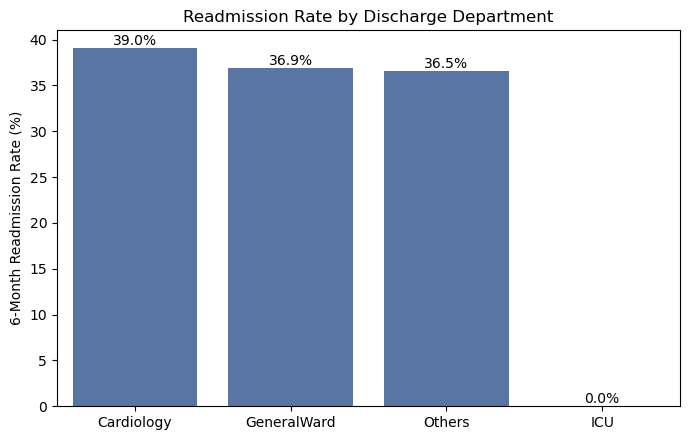

In [46]:
# 📊 Chart: 6-month readmission rate by discharge department
import matplotlib.pyplot as plt
import seaborn as sns

dept_plot = df.groupby('discharge_department').agg(
    n=('patient_id','nunique'), readmit_6m=('readmission_6m','mean')
).reset_index()
dept_plot['readmit_6m'] *= 100
dept_plot = dept_plot.sort_values('readmit_6m', ascending=False)

plt.figure(figsize=(7,4.5))
ax = sns.barplot(data=dept_plot, x='discharge_department', y='readmit_6m', color='#4C72B0')
ax.set_ylabel('6-Month Readmission Rate (%)')
ax.set_xlabel('')
ax.set_title('Readmission Rate by Discharge Department')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')
plt.tight_layout()
plt.show()


### 📌 In Simple Terms
Look at the chart — Cardiology, General Ward and Others are almost the same height (about 37–39%). The gap between Cardiology and General Ward is only about 2 percentage points, so roughly the same share of patients come back no matter which ward discharged them. ICU shows 0%, but that is only 12 patients — far too few to mean anything. **Don't build a special follow-up plan based on the ward a patient left from — base it on the patient's own health risks instead.**

### Key Insights
- **Readmission rates are very similar across the main departments:** Cardiology **39.05%** (n = 1,703), General Ward **36.93%** (n = 241), Others **36.54%** (n = 52).
- **The Cardiology vs General Ward gap is only 2.12 percentage points** — too small to justify running two different follow-up systems.
- **ICU shows 0% readmission, but only 12 patients were discharged from ICU**, so this rate is unreliable and should not guide policy.
- **Department is not where readmission risk lies.** About 4 in 10 patients are readmitted within 6 months whichever ward they leave from, so the risk comes from the patients themselves — their severity, kidney function and other clinical markers (see Questions 6 and 16) — not from the department.

### Prescriptive Action to be taken
- **Do not create separate follow-up protocols by discharge department** — the readmission rates do not differ enough to support it.
- **Allocate follow-up intensity by patient-level risk instead:** heart-failure severity and emergency admission (Question 6), kidney stage (Question 16), and other clinical markers identified in this notebook.
- **Apply one standard discharge and follow-up process across all departments**, since readmission is high (about 37–39%) everywhere.

## 14. Does occupation (a proxy for rural vs urban living) change readmission rates? 


### Reasoning
Occupation is used here as an indirect proxy for geographic and socioeconomic context (e.g., "Farmer" suggesting rural residence, "Urban resident" suggesting city living) since the dataset has no direct address, zip code, or urban/rural flag. This matters operationally because rural patients often face longer travel distances to follow-up clinics, less access to home health services, and different care-seeking patterns — all of which could independently affect readmission risk regardless of clinical severity. We compare the 6-month readmission rate across occupation groups, together with the number of patients in each group, since rates from very small groups are unreliable. This is an unadjusted comparison — occupation groups may also differ in age or illness severity — so any gap is a signal to investigate, not proof of an effect.

### Metrics Biomarkers and Features used
occupation
readmission_6m
patient_id (number of patients per occupation group)
### Why used
occupation — the primary variable being tested, used as the best available proxy in this dataset for rural vs. urban residence, since no direct geographic field exists.
readmission_6m — the outcome of interest; chosen since it has enough events (773 total) across occupation subgroups to support a meaningful comparison.
patient_id (n per group) — shows how much each rate can be trusted; Officer (n = 7), Worker (n = 17) and Unknown (n = 27) are too small to interpret on their own.

In [47]:
occ_summary = df.groupby('occupation').agg(
    n=('patient_id','nunique'), readmit_6m=('readmission_6m','mean')
)
occ_summary['readmit_6m'] *= 100
# Add % sign for display
occ_summary['readmit_6m'] = occ_summary['readmit_6m'].round(2).astype(str) + '%'

#print(occ_summary.sort_values('readmit_6m', ascending=False).round(2))
print(occ_summary.sort_values('readmit_6m', ascending=False))

                  n readmit_6m
occupation                    
Unknown          27     59.26%
Officer           7     42.86%
Others           89      42.7%
Urbanresident  1670     39.82%
Farmer          198     24.24%
Worker           17     17.65%


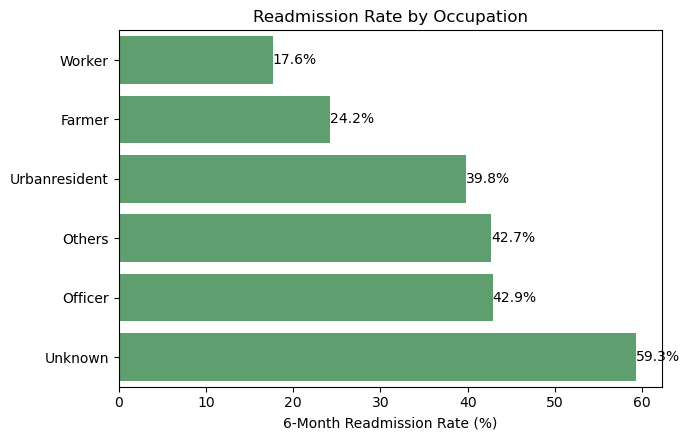

In [48]:
# Chart: 6-month readmission rate by occupation
import matplotlib.pyplot as plt
import seaborn as sns

occ_plot = df.groupby('occupation').agg(
    n=('patient_id','nunique'), readmit_6m=('readmission_6m','mean')
).reset_index()
occ_plot['readmit_6m'] *= 100
occ_plot = occ_plot.sort_values('readmit_6m', ascending=True)

plt.figure(figsize=(7,4.5))
ax = sns.barplot(data=occ_plot, y='occupation', x='readmit_6m', color='#55A868')
ax.set_xlabel('6-Month Readmission Rate (%)')
ax.set_ylabel('')
ax.set_title('Readmission Rate by Occupation')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')
plt.tight_layout()
plt.show()


### In Simple Terms
Farmers (our best stand-in for "lives in a rural area") have the **lowest** readmission rate of
any large group (24%, vs 40% for urban residents). Only "Worker" is lower (18%), but that is just 17 patients. This is surprising, since rural patients
usually have *worse* access to follow-up care, not better outcomes. **Possible explanation:**
rural patients may simply not come back to *this* hospital for a milder relapse — they could be
getting readmitted somewhere closer to home that this dataset doesn't see. **This needs more
digging before treating "farmers do better" as a real, trustworthy finding.**

### Key Insights
- **Farmers (proxy for rural)** show a notably lower readmission rate (**24.2%**, n = 198) than urban residents (**39.8%**, n = 1,670) — the opposite of what a "rural access barrier" hypothesis would predict.
- This could reflect a real protective factor, but more plausibly reflects **selection bias**: rural/farmer patients may only return to this specific hospital for severe re-admissions, with milder relapses handled locally or not captured at all — so the true rural readmission rate could be undercounted, not actually lower.
- **Small groups are unreliable:** Unknown 59.3% (n = 27), Officer 42.9% (n = 7), Worker 17.6% (n = 17).
- The comparison is **unadjusted** — farmers may also differ in age or severity.
### Prescriptive Action to be taken
Don't treat this as "farmers are lower-risk" — it more likely flags a data-capture gap for rural patients that needs investigating (e.g., checking if rural patients have more Unknown outcomes or drop out of follow-up, and linking with other hospitals' readmission records) before any follow-up intensity recommendation is made.

## 15. Do patients who never had an echo recorded do worse (a care-process gap)? 



### Reasoning
Echocardiography is a core diagnostic test in heart failure management — it's how clinicians assess ejection fraction, valve function, and overall cardiac structure, all of which directly inform medication choice and discharge planning. A patient never getting one recorded during their admission is a potential care-process gap rather than a clinical variable in itself — it reflects something about how the patient was managed, not something about their underlying biology. This distinction matters: if patients without an echo do worse, it could mean either (a) sicker/unstable patients don't tolerate or get scheduled for the test in time, or (b) missing the echo itself leads to under-treatment (e.g., an undiagnosed low ejection fraction never gets appropriately medicated). We compare the 6-month readmission and mortality rates of patients with and without any echo measurement recorded. This is an unadjusted comparison, so it shows whether a gap exists and how large it is, but cannot on its own separate explanation (a) from (b).

### Metrics Biomarkers and Features used

heart_pumping_efficiency, left_ventricle_size, mitral_valve_ems, ea_ratio, pulmonary_velocity → combined into a derived echo_recorded flag
readmission_6m
death_6m

### Why used
The five echo fields → echo_recorded — since no single "echo done: yes/no" flag exists in the dataset, this derived variable was built by checking whether any of the five echo-related measurements has a non-missing value for a patient; using .any() rather than checking one field alone correctly captures partial echo reports where only some measurements were recorded.
readmission_6m and death_6m — both checked separately since the question implies a general "do worse" outcome, and a process gap could show up more strongly in one outcome than the other — readmission shows a large gap (17 points) while the mortality gap is small (0.9 points).

In [49]:
#Importing all the Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.simplefilter("ignore", UserWarning)
#df = pd.read_csv('wide_merged_table.csv', low_memory=False)
df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv",low_memory=False)
echo_cols = ['heart_pumping_efficiency','left_ventricle_size','mitral_valve_ems','ea_ratio','pulmonary_velocity']
df = df.copy()
#df['echo_recorded'] = df[echo_cols].notna().any(axis=1).astype(int)
df['echo_recorded'] = df[echo_cols].notna().any(axis=1).map({True: 'Yes', False: 'No'})

echo_summary = df.groupby('echo_recorded').agg(
    n=('patient_id','nunique'), readmit_6m=('readmission_6m','mean'), death_6m=('death_6m','mean')
)
echo_summary[['readmit_6m','death_6m']] *= 100
echo_summary[['readmit_6m','death_6m']]=echo_summary[['readmit_6m','death_6m']].round(2).astype(str) + '%'
#print(echo_summary.round(2))
print(echo_summary)

                  n readmit_6m death_6m
echo_recorded                          
No              637     50.08%    3.45%
Yes            1371     33.11%    2.55%


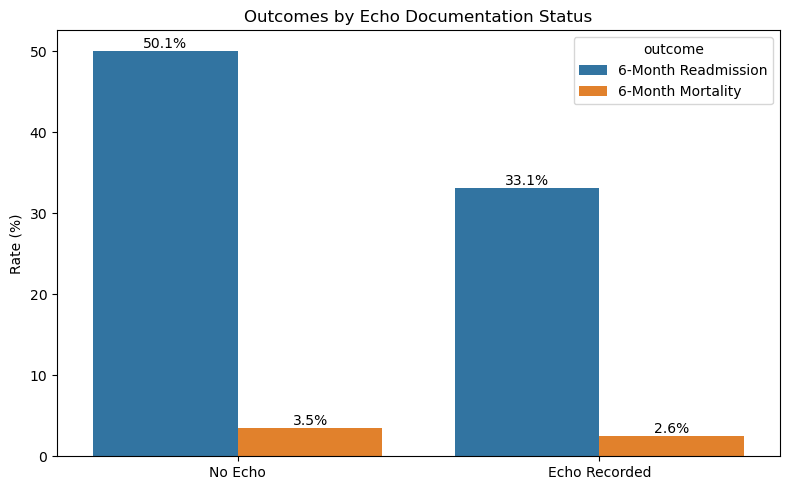

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

echo_cols = ['heart_pumping_efficiency','left_ventricle_size','mitral_valve_ems','ea_ratio','pulmonary_velocity']

# Rebuild the flag fresh, guaranteed 0/1 only
df['echo_recorded'] = df[echo_cols].notna().any(axis=1).astype(int)

# Confirm it's clean before plotting
#print(df['echo_recorded'].value_counts())

echo_summary = df.groupby('echo_recorded').agg(
    n=('patient_id', 'nunique'),
    readmit_6m=('readmission_6m', 'mean'),
    death_6m=('death_6m', 'mean')
).reset_index()

# Multiply by 100 BEFORE melting - do it on the reset_index copy
echo_summary['readmit_6m'] = echo_summary['readmit_6m'] * 100
echo_summary['death_6m'] = echo_summary['death_6m'] * 100
echo_summary['echo_recorded'] = echo_summary['echo_recorded'].map({0: 'No Echo', 1: 'Echo Recorded'})

plot_data = echo_summary.melt(
    id_vars='echo_recorded', value_vars=['readmit_6m', 'death_6m'],
    var_name='outcome', value_name='rate'
)
plot_data['outcome'] = plot_data['outcome'].map({
    'readmit_6m': '6-Month Readmission', 'death_6m': '6-Month Mortality'
})

#print(plot_data)  # sanity check the numbers look right before plotting

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=plot_data, x='echo_recorded', y='rate', hue='outcome')
ax.set_ylabel('Rate (%)')
ax.set_xlabel('')
ax.set_title('Outcomes by Echo Documentation Status')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')
plt.tight_layout()
plt.show()

### Key Insights
- Patients with **no echo recorded** (n = 637) have a much higher 6-month readmission rate — **50.1% vs 33.1%** (n = 1,371), a 17-point gap.
- Mortality is only slightly higher (**3.45% vs 2.55%**).
- Two explanations are possible: (a) sicker or unstable patients don't get an echo during a rushed admission, or (b) missing the echo is itself a care-process gap that leads to under-treatment (e.g., a missed low ejection fraction → sub-optimal medicines). This comparison is unadjusted, so it cannot tell which is true — but either way, the missing echo marks a high-risk patient.
### Prescriptive Action to be taken
- Make a **completed echo a mandatory pre-discharge checklist item** for every heart-failure admission — it is a process fix (order the test), not a hard clinical trade-off.
- Until the echo is done, treat "no echo" patients as **high readmission risk**: early follow-up within 7–14 days and an outpatient echo booked before discharge.

###  In Simple Terms
Patients who never got an echocardiogram (echo) were readmitted much more often — **50%** vs **33%** for those who did get one. This simple comparison doesn't adjust for how sick the patients were, but the gap is large. **Simple fix: make sure every heart failure patient gets an echo before they go home** — it's a cheap, existing test that helps doctors pick the right medication.

## 16. How does kidney function (eGFR stage) relate to death and readmission — is the relationship linear? 

### Reasoning
Kidney function is one of the strongest prognostic markers in heart failure: a weak heart reduces blood flow to the kidneys, and failing kidneys retain salt and water, which worsens the heart (the **cardio-renal** link). Most risk scores treat eGFR as a straight line — "the lower the eGFR, the higher the risk". If that is not true, a single linear score will send follow-up resources to the wrong patients. We therefore grouped patients into the standard KDIGO kidney stages (G1 best → G5 worst) and compared **6-month readmission** and **6-month mortality** stage by stage, to see where each risk actually concentrates.

### Metrics Biomarkers and Features used
- **glomerular_filtration_rate (eGFR, mL/min/1.73m²)** → recoded into KDIGO stages: G1 ≥ 90, G2 60–89, G3a 45–59, G3b 30–44, G4 15–29, G5 < 15 (1,945 patients with eGFR recorded)
- **readmission_6m** — readmitted within 6 months (outcome 1)
- **death_6m** — died within 6 months (outcome 2)
- Pearson correlation between raw eGFR and death_6m (tests how well a straight-line relationship describes the data)

### Why used
- **eGFR** is the routine, universally available measure of kidney function and is already used by clinicians to stage chronic kidney disease.
- **KDIGO stages** instead of arbitrary bins, so the results translate directly into thresholds doctors already know and use.
- **Two outcomes separately**, because kidney failure can affect readmission and death in different ways — a patient who dies cannot be readmitted, so the two risks can move in opposite directions.
- **Correlation with death** checks the linear assumption: a weak correlation alongside large differences between stages means the risk is concentrated in specific ranges rather than rising smoothly.

In [51]:
def gfr_stage(g):
    if pd.isna(g): return None
    if g >= 90: return 'G1 (>=90)'
    elif g >= 60: return 'G2 (60-89)'
    elif g >= 45: return 'G3a (45-59)'
    elif g >= 30: return 'G3b (30-44)'
    elif g >= 15: return 'G4 (15-29)'
    else: return 'G5 (<15)'

df['gfr_stage'] = df['glomerular_filtration_rate'].apply(gfr_stage)
stage_order = ['G1 (>=90)','G2 (60-89)','G3a (45-59)','G3b (30-44)','G4 (15-29)','G5 (<15)']
stage_summary = df.groupby('gfr_stage').agg(
    n=('patient_id','nunique'), readmit_6m=('readmission_6m','mean'), death_6m=('death_6m','mean')
).reindex(stage_order)
stage_summary[['readmit_6m','death_6m']] *= 100
print(stage_summary.round(2))

corr = df.dropna(subset=['glomerular_filtration_rate'])[['glomerular_filtration_rate','death_6m']].corr()
print(corr)

               n  readmit_6m  death_6m
gfr_stage                             
G1 (>=90)    491       30.75      1.63
G2 (60-89)   568       36.09      2.29
G3a (45-59)  330       44.55      1.52
G3b (30-44)  304       50.00      2.96
G4 (15-29)   176       40.91      7.95
G5 (<15)      76       34.21      9.21
                            glomerular_filtration_rate  death_6m
glomerular_filtration_rate                    1.000000 -0.095701
death_6m                                     -0.095701  1.000000


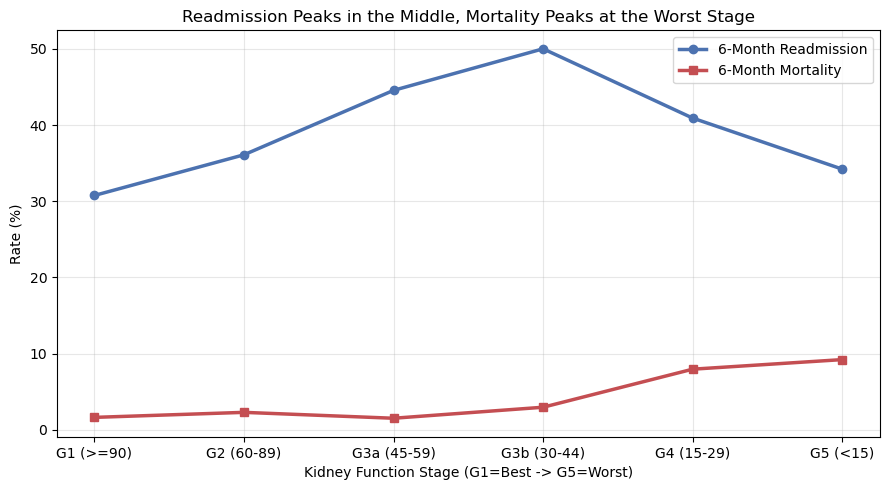

In [52]:
# 📊 Chart: Readmission vs Mortality by kidney function stage — showing the NON-linear shape
import matplotlib.pyplot as plt

stage_order = ['G1 (>=90)','G2 (60-89)','G3a (45-59)','G3b (30-44)','G4 (15-29)','G5 (<15)']
plot_df = stage_summary.reindex(stage_order)

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(stage_order, plot_df['readmit_6m'], marker='o', linewidth=2.5, label='6-Month Readmission', color='#4C72B0')
ax.plot(stage_order, plot_df['death_6m'], marker='s', linewidth=2.5, label='6-Month Mortality', color='#C44E52')
ax.set_ylabel('Rate (%)')
ax.set_xlabel('Kidney Function Stage (G1=Best -> G5=Worst)')
ax.set_title('Readmission Peaks in the Middle, Mortality Peaks at the Worst Stage')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### In Simple Terms
Kidney trouble is not one simple, steadily rising risk — it is **two different risks that peak at different stages**:
- **Readmission (blue line)** climbs from 31% at G1 to a peak of **50% at G3b**, then falls back to 34% at G5.
- **Death (red line)** stays low (1.5–3%) until G3b and then jumps to **8% at G4 and 9% at G5**.

Patients with moderate kidney disease keep coming back to hospital; patients with severe kidney failure are more likely to die — often before they have the chance to be readmitted. One "worse kidneys = worse" rule would miss both groups.

### Key Insights
- **Readmission follows an inverted-U shape.** 6-month readmission rises from **30.8% (G1)** → 36.1% (G2) → 44.6% (G3a) → **50.0% (G3b, peak)**, then falls to 40.9% (G4) and 34.2% (G5). Patients with moderate CKD (G3a + G3b, n = 634) are readmitted **47%** of the time — about 1.5× the rate of patients with normal kidneys.
- **Mortality rises sharply only at the severe end.** 6-month death is 1.5–3.0% for G1 to G3b but **7.95% at G4** and **9.21% at G5**. Patients with eGFR < 30 (n = 252) die at about **8.3%**, roughly **4× the 2.1%** seen in patients with eGFR ≥ 30.
- **A straight-line view hides this.** The correlation between raw eGFR and death is only **−0.10**, even though mortality differs ~4-fold between stages — the risk is concentrated in specific ranges, not spread evenly.
- **Competing risk explains the divergence:** the sickest kidney patients (G4/G5) are more likely to die before they can be readmitted, which pulls their readmission rate down while their mortality keeps climbing.
- **Clinical meaning:** kidney stage identifies two different high-risk groups needing two different interventions — a readmission-prevention group (G3a/G3b) and a mortality-prevention group (G4/G5).

### Prescriptive Action to be taken
- **Replace any linear eGFR score with a stage-based rule** applied at discharge.
- **eGFR 30–59 (G3a/G3b) → readmission-prevention pathway:** follow-up clinic within 7–14 days, repeat creatinine/eGFR and potassium within 1–2 weeks, diuretic dose review, fluid/weight monitoring and medication reconciliation.
- **eGFR < 30 (G4/G5) → mortality-prevention pathway:** nephrology co-management before discharge, careful dosing of renally-cleared drugs and avoidance of nephrotoxic agents (e.g., NSAIDs), close potassium monitoring, and an early goals-of-care / advance-care-planning discussion.
- **eGFR ≥ 60 (G1/G2):** standard follow-up.
- Record eGFR for every heart-failure admission (63 patients had none) so every patient can be staged.

## 17. How dangerous is high potassium, and how does it interact with spironolactone (MRA) prescribing? 

### Reasoning
Potassium and spironolactone (an MRA) are clinically linked by a well-known safety concern: MRAs work by blocking aldosterone, which causes the kidney to retain potassium as a side effect — meaning MRA use can itself push potassium higher, especially in patients who already have reduced kidney function. This creates a two-part question: first, how dangerous is elevated potassium on its own, and second, does being on spironolactone make that danger worse (an interaction effect), or are the two risks independent of each other?

### Metrics Biomarkers and Features used
potassium → recoded into K_group (5 clinical bands) and a collapsed hyperK (>5.0 binary flag)
drug_Spironolactone_Tablet
death_6m
readmission_6m
age_mid (derived from age_category)
glomerular_filtration_rate (eGFR)
diabetes
sex_male (derived from gender)
### Why used
potassium → K_group / hyperK — the primary exposure. The clinical bands (hypokalemia < 3.5, normal 3.5–5.0, mild 5.1–5.5, moderate 5.6–6.0, severe > 6.0 mmol/L) follow standard hyperkalemia grading so the results map onto thresholds clinicians already use. It was then collapsed into a single hyperK flag (> 5.0) because the full band-by-drug interaction model was unstable (sparse cells produced huge/undefined odds ratios).
drug_Spironolactone_Tablet — the MRA whose potassium-raising effect is the safety concern; used descriptively (% on spironolactone in each potassium band) and as the interaction term hyperK × spironolactone to test whether the drug makes high potassium more dangerous.
death_6m and readmission_6m — the two outcomes; checked separately because potassium and spironolactone could affect death and readmission differently (and they did).
glomerular_filtration_rate (eGFR) — the kidneys clear potassium, so low eGFR both raises potassium and independently raises mortality; it is the key confounder to adjust for (it was significant in both models, p ≤ 0.003).
age_mid, diabetes, sex_male — standard adjustment variables; diabetes is included because it is associated with higher potassium (reduced aldosterone activity) and independently with readmission (OR 1.48, p = 0.0004).

In [53]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv",low_memory=False)

age_mid_map = {'21-29':25,'29-39':34,'39-49':44,'49-59':54,'59-69':64,'69-79':74,'79-89':84,'89-110':95}
df['age_mid'] = df['age_category'].map(age_mid_map)
df['sex_male'] = (df['gender'] == 'Male').astype(int)

def logistic_model(formula, data):
    model = smf.logit(formula, data=data).fit(disp=False)
    return pd.DataFrame({
        "OR": np.exp(model.params), "CI_lower": np.exp(model.conf_int()[0]),
        "CI_upper": np.exp(model.conf_int()[1]), "p_value": model.pvalues
    })

# 1. Potassium bands - crude outcomes and spironolactone use
def k_band(k):
    if pd.isna(k): return None
    if k < 3.5: return 'Hypokalemia (<3.5)'
    elif k <= 5.0: return 'Normal (3.5-5.0)'
    elif k <= 5.5: return 'Mild Hyper (5.1-5.5)'
    elif k <= 6.0: return 'Moderate Hyper (5.6-6.0)'
    else: return 'Severe Hyper (>6.0)'

df['K_group'] = df['potassium'].apply(k_band)
k_order = ['Hypokalemia (<3.5)','Normal (3.5-5.0)','Mild Hyper (5.1-5.5)',
           'Moderate Hyper (5.6-6.0)','Severe Hyper (>6.0)']

K_table = df.groupby('K_group', observed=False).agg(
    n=('patient_id', 'nunique'),
    pct_on_spironolactone=('drug_Spironolactone_Tablet', 'mean'),
    death_6m=('death_6m', 'mean'),
    readmit_6m=('readmission_6m', 'mean')
).reindex(k_order)
for c in ['pct_on_spironolactone','death_6m','readmit_6m']:
    K_table[c] = (K_table[c] * 100).round(2)
print(K_table)

# 2. Full 6-band interaction (mortality) - EXPECT INSTABILITY (sparse cells)
d = df.dropna(subset=['potassium', 'glomerular_filtration_rate', 'age_mid'])
formula_full = ("death_6m ~ C(K_group) * drug_Spironolactone_Tablet + "
                 "age_mid + glomerular_filtration_rate + diabetes + sex_male")
print(logistic_model(formula_full, d).round(4))   # will show huge/undefined ORs — do not report these

# 3. Collapsed hyperkalemia (>5.0) x spironolactone - STABLE version
d['hyperK'] = (d['potassium'] > 5.0).astype(int)

formula_mort = "death_6m ~ hyperK * drug_Spironolactone_Tablet + age_mid + glomerular_filtration_rate + diabetes + sex_male"
print(logistic_model(formula_mort, d).round(4))

formula_readm = "readmission_6m ~ hyperK * drug_Spironolactone_Tablet + age_mid + glomerular_filtration_rate + diabetes + sex_male"
print(logistic_model(formula_readm, d).round(4))
print(f"n = {len(d)}")

                             n  pct_on_spironolactone  death_6m  readmit_6m
K_group                                                                    
Hypokalemia (<3.5)         465                  94.84      1.94       33.98
Normal (3.5-5.0)          1369                  91.09      2.34       39.01
Mild Hyper (5.1-5.5)       101                  88.12      6.93       46.53
Moderate Hyper (5.6-6.0)    35                  77.14     11.43       57.14
Severe Hyper (>6.0)         27                  77.78     14.81       37.04
                                                              OR  CI_lower  \
Intercept                                           0.000000e+00    0.0000   
C(K_group)[T.Mild Hyper (5.1-5.5)]                  1.020000e-02    0.0000   
C(K_group)[T.Moderate Hyper (5.6-6.0)]              1.236179e+07    0.0000   
C(K_group)[T.Normal (3.5-5.0)]                      2.238891e+06    0.0000   
C(K_group)[T.Severe Hyper (>6.0)]                   3.669268e+06    0.0000   


C:\Users\sneha\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


High potassium on its own is genuinely dangerous (Table 1 shows this clearly — death rate keeps climbing).

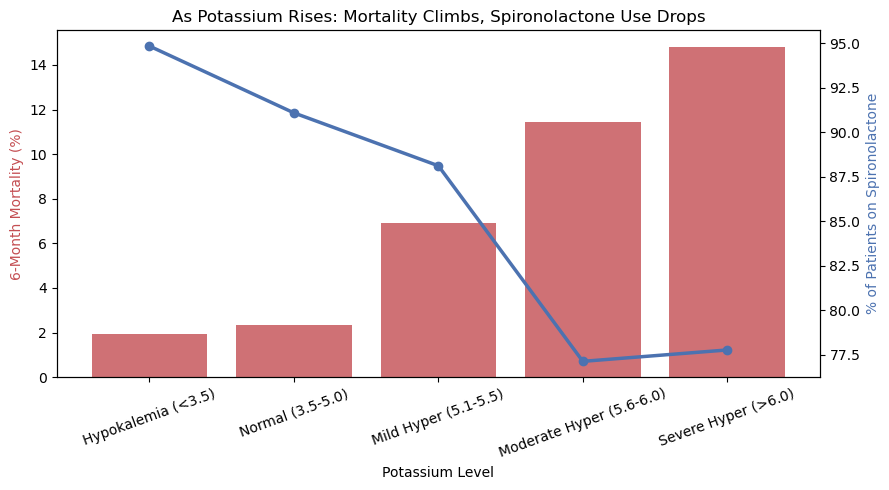

In [54]:
# 📊 Chart: Mortality and spironolactone use across potassium levels
import matplotlib.pyplot as plt

k_order = ['Hypokalemia (<3.5)','Normal (3.5-5.0)','Mild Hyper (5.1-5.5)',
           'Moderate Hyper (5.6-6.0)','Severe Hyper (>6.0)']
plot_df = K_table.reindex(k_order)

fig, ax1 = plt.subplots(figsize=(9,5))
ax1.bar(k_order, plot_df['death_6m'], color='#C44E52', alpha=0.8, label='6-Month Mortality (%)')
ax1.set_ylabel('6-Month Mortality (%)', color='#C44E52')
ax1.set_xlabel('Potassium Level')
plt.xticks(rotation=20)

ax2 = ax1.twinx()
ax2.plot(k_order, plot_df['pct_on_spironolactone'], marker='o', linewidth=2.5,
         color='#4C72B0', label='% on Spironolactone')
ax2.set_ylabel('% of Patients on Spironolactone', color='#4C72B0')

ax1.set_title('As Potassium Rises: Mortality Climbs, Spironolactone Use Drops')
fig.tight_layout()
plt.show()


###  In Simple Terms
The red bars (death rate) get taller as potassium rises — from under 2% up to nearly 15%.
Meanwhile the blue line (percent of patients on the heart drug spironolactone) trends downward —
doctors are already backing off this medication as potassium gets dangerous. **The good news:**
when we tested it directly, high potassium does NOT make spironolactone extra dangerous — the two
risks are independent. **Action: watch potassium closely and treat it seriously on its own (flag
anything above 5.0 and act at ≥5.5), regardless of which heart medications a patient is taking.**

### Key Insights
- **Higher potassium = higher risk of death.** From low potassium (hypokalaemia) to severely high, 6-month death rises steadily: **1.9% → 2.3% → 6.9% → 11.4% → 14.8%** — roughly an **8× jump** from the lowest to the highest group. Risk already **triples** in the mild band (5.1–5.5: 6.9% vs 2.3% with normal potassium). Potassium is a genuine danger signal on its own.
- **Doctors are already cautious with spironolactone as potassium rises.** Use falls from **91%** (normal potassium; 95% in hypokalaemia) to **77–78%** (moderate/severe high potassium) — but more than three-quarters of patients with potassium above 5.5 are still on it.
- **High potassium does NOT make spironolactone specifically more dangerous.** The hyperK × spironolactone interaction was not significant (p = 0.57 for death, p = 0.93 for readmission). The two risks act independently, not as a "double danger".
- **Spironolactone shows a mixed picture:** lower death risk (OR 0.35, p = 0.009) but higher readmission risk (OR 1.95, p = 0.0008). This likely reflects which patients get the drug rather than the drug itself causing either effect.
- **Kidney function matters in both models** (eGFR p ≤ 0.003), and diabetes is linked to readmission (OR 1.48, p = 0.0004).
- The full 5-band model broke down (huge/undefined odds ratios) because some potassium/drug combinations had too few patients; the simplified 2-group version (high vs not high potassium) gave the trustworthy numbers.

### Prescriptive Action to be taken
- **Potassium > 5.0** → automatic flag for closer monitoring (repeat potassium and eGFR within 48–72 hours and before discharge).
- **Potassium ≥ 5.5** → potassium-lowering treatment and review of potassium-raising drugs: reduce or temporarily hold spironolactone and stop potassium supplements, in line with heart-failure guidelines.
- Don't withdraw spironolactone from patients with normal potassium — it was associated with lower mortality.

## 18. Do men and women differ in HF type and in outcomes?
### Reasoning
Heart failure (HF) means the heart cannot pump enough blood for the body's needs. It comes in different types, and the type decides which medicines help. Women are often thought to have the "stiff heart" type and men the "weak pump" type. We check whether that is true here and whether outcomes differ by sex.

### Metrics Biomarkers and Features used
* **Sex:** `gender` (Female / Male)
* **Side of the heart that is failing:** `heart_failure_type`: Left, Right or Both sides
* **Left ventricular ejection fraction (LVEF):** `heart_pumping_efficiency`, the % of blood the main pumping chamber pushes out with each beat (normal ≥ 50%). It is measured by an **echocardiogram (echo)**, an ultrasound scan of the heart. Grouped as:
  * **HF with reduced ejection fraction (HFrEF):** LVEF below 40%, a weak pump
  * **HF with mildly reduced ejection fraction (HFmrEF):** LVEF 40–49%
  * **HF with preserved ejection fraction (HFpEF):** LVEF 50% or more, a stiff heart that pumps normally but fills poorly
* **Outcomes:** `death_6m` (died within 6 months), `readmission_6m` (readmitted to hospital within 6 months)

### Why used
HF type decides treatment: the proven heart-failure medicines work best in HFrEF. Comparing outcomes by sex shows whether either group needs extra follow-up.

Heart-failure type (% of each sex):
heart_failure_type  Both  Left  Right
gender                               
Female              73.5  23.6    2.8
Male                74.0  23.9    2.1

Ejection-fraction type among patients with an echo (%):
phenotype  HFrEF (<40%)  HFmrEF (40-49%)  HFpEF (>=50%)
gender                                                 
Female             16.4             22.6           60.9
Male               26.9             25.8           47.3

Outcomes:
        patients  death_6m  readmission_6m
gender                                    
Female      1163       2.4            37.7
Male         845       3.4            39.6


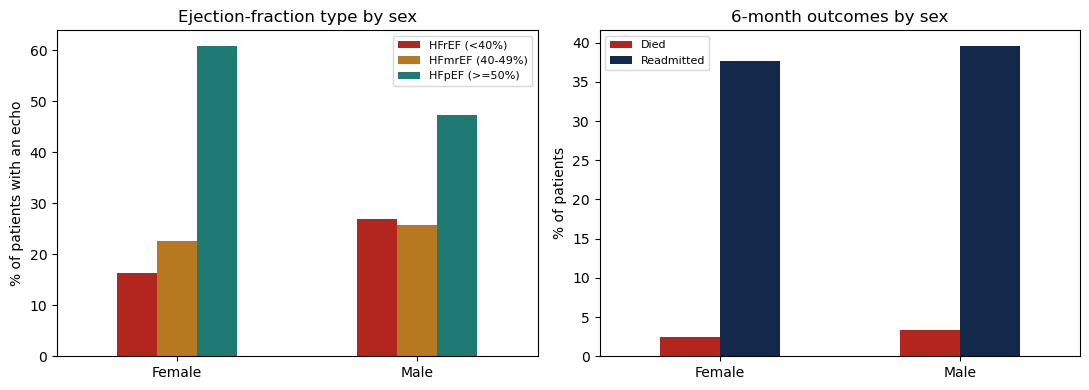

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

def rate_table(data, group, outcome):
    """Patients, events and event rate (%) of a 0/1 outcome for each group."""
    t = data.groupby(group, observed=True)[outcome].agg(patients="size", events="sum")
    t["rate_%"] = (t["events"] / t["patients"] * 100).round(1)
    return t
hf_type = pd.crosstab(df["gender"], df["heart_failure_type"], normalize="index").mul(100).round(1)
echo = df[df["heart_pumping_efficiency"].notna()].copy()
echo["phenotype"] = pd.cut(echo["heart_pumping_efficiency"], [0, 40, 50, 100], right=False, labels=["HFrEF (<40%)", "HFmrEF (40-49%)", "HFpEF (>=50%)"])
phenotype = pd.crosstab(echo["gender"], echo["phenotype"], normalize="index").mul(100).round(1)
outcomes = df.groupby("gender").agg(patients=("patient_id", "size"),
                                    death_6m=("death_6m", lambda s: round(s.mean() * 100, 1)),
                                    readmission_6m=("readmission_6m", lambda s: round(s.mean() * 100, 1)))
print("Heart-failure type (% of each sex):"); print(hf_type); print("\nEjection-fraction type among patients with an echo (%):"); print(phenotype)
print("\nOutcomes:"); print(outcomes)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
phenotype.plot.bar(ax=ax[0], rot=0, color=["#B3261E", "#B7791F", "#1F7A74"])
ax[0].set_ylabel("% of patients with an echo"); ax[0].set_xlabel(""); ax[0].set_title("Ejection-fraction type by sex"); ax[0].legend(fontsize=8)
outcomes[["death_6m", "readmission_6m"]].plot.bar(ax=ax[1], rot=0, color=["#B3261E", "#13294B"])
ax[1].set_ylabel("% of patients"); ax[1].set_xlabel(""); ax[1].set_title("6-month outcomes by sex"); ax[1].legend(["Died", "Readmitted"], fontsize=8)
plt.tight_layout()
plt.show()

### Key Insights
**How to read the chart:** Left panel: for women and for men, the three coloured bars show how their patients (those who had an echo) split across the three LVEF types; each sex's bars add up to 100%. Right panel: for each sex, the red bar is the % who died and the navy bar the % readmitted within 6 months. Taller bar = more common.

* The failing side (`heart_failure_type`) is almost identical for men and women (both sides: 73.5% of women, 74.0% of men).
* **The pump type differs:** women more often have the stiff-heart type **HFpEF** (60.9% vs 47.3%); men more often have the weak-pump type **HFrEF** (26.9% vs 16.4%).
* **Outcomes are similar:** 6-month death 2.4% (women) vs 3.4% (men); 6-month readmission 37.7% vs 39.6%.

### Prescriptive Action to be taken
* Give **every patient an echo**, because men are more likely to have HFrEF, which needs the full set of heart-failure medicines.
* For women with HFpEF, focus on controlling blood pressure, fluid and other conditions.
* Follow-up does not need to differ by sex.

## 19. Is HFpEF "milder" than HFrEF in terms of outcomes?
### Reasoning
**HFpEF** (heart failure with preserved ejection fraction: the heart pumps normally but is stiff and fills poorly) is sometimes treated as the milder form compared with **HFrEF** (heart failure with reduced ejection fraction: a weak pump). If outcomes are similar, HFpEF patients deserve the same attention.

### Metrics Biomarkers and Features used
* **Left ventricular ejection fraction (LVEF):** `heart_pumping_efficiency`, the % of blood pushed out per beat, from the echocardiogram (echo, an ultrasound scan of the heart). Groups: HFrEF < 40%, **HFmrEF** (mildly reduced ejection fraction) 40–49%, HFpEF ≥ 50%
* **Outcomes:** `death_6m`, `readmission_6m`
* **Length of stay:** `discharge_day` (days in hospital)

### Why used
These are the standard groups doctors use to choose treatment. Outcomes and length of stay show how serious each type is.

Patients with an echo: 635 of 2008
6-month death:
                 patients  events  rate_%
phenotype                                
HFrEF (<40%)          132       2     1.5
HFmrEF (40-49%)       152       1     0.7
HFpEF (>=50%)         351       7     2.0

6-month readmission:
                 patients  events  rate_%
phenotype                                
HFrEF (<40%)          132      57    43.2
HFmrEF (40-49%)       152      55    36.2
HFpEF (>=50%)         351     142    40.5

Median stay (days): {'HFrEF (<40%)': 8.0, 'HFmrEF (40-49%)': 8.0, 'HFpEF (>=50%)': 7.0}


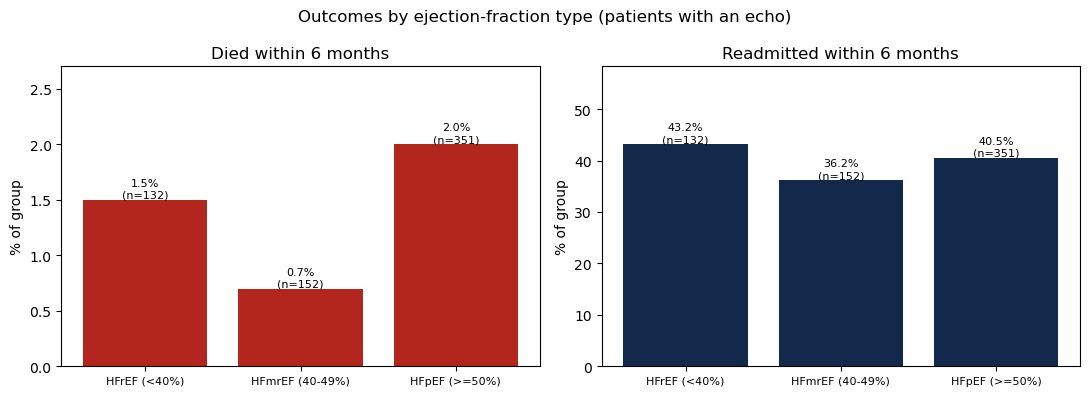

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

def rate_table(data, group, outcome):
    """Patients, events and event rate (%) of a 0/1 outcome for each group."""
    t = data.groupby(group, observed=True)[outcome].agg(patients="size", events="sum")
    t["rate_%"] = (t["events"] / t["patients"] * 100).round(1)
    return t
echo = df[df["heart_pumping_efficiency"].notna()].copy()
echo["phenotype"] = pd.cut(echo["heart_pumping_efficiency"], [0, 40, 50, 100], right=False, labels=["HFrEF (<40%)", "HFmrEF (40-49%)", "HFpEF (>=50%)"])
death = rate_table(echo, "phenotype", "death_6m"); readm = rate_table(echo, "phenotype", "readmission_6m")
stay = echo.groupby("phenotype", observed=True)["discharge_day"].median()
print("Patients with an echo:", len(echo), "of", len(df))
print("6-month death:"); print(death); print("\n6-month readmission:"); print(readm); print("\nMedian stay (days):", stay.to_dict())

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, t, title, col in [(ax[0], death, "Died within 6 months", "#B3261E"), (ax[1], readm, "Readmitted within 6 months", "#13294B")]:
    b = a.bar(t.index.astype(str), t["rate_%"], color=col)
    for bb, r, n in zip(b, t["rate_%"], t["patients"]):
        a.text(bb.get_x() + bb.get_width() / 2, r, f"{r}%\n(n={n})", ha="center", va="bottom", fontsize=8)
    a.set_title(title); a.set_ylabel("% of group"); a.set_ylim(0, t["rate_%"].max() * 1.35); a.tick_params(axis="x", labelsize=8)
fig.suptitle("Outcomes by ejection-fraction type (patients with an echo)")
plt.tight_layout()
plt.show()

### Key Insights
**How to read the chart:** Two charts with the same three groups (weak pump on the left, stiff heart on the right). Left chart: % who died within 6 months. Right chart: % readmitted within 6 months. The label on each bar gives the % and the number of patients (n). Similar bar heights mean similar risk.

* Only 635 of 2,008 patients (32%) have an echo recorded (`heart_pumping_efficiency` present), so groups are small.
* **HFpEF is not milder:** readmission 40.5% vs 43.2% for HFrEF; 6-month death 2.0% vs 1.5% (very few deaths in either group).
* Hospital stays are similar (median 7 vs 8 days).

### Prescriptive Action to be taken
* Give HFpEF patients the **same follow-up intensity** as HFrEF patients.
* Treat what drives HFpEF: high blood pressure, an irregular heartbeat (**atrial fibrillation**), diabetes and kidney disease.

## 20. Does low sodium (hyponatraemia) predict early readmission?
### Reasoning
**Sodium** is the main salt in the blood. **Hyponatraemia** means blood sodium is too low (below 135 mmol/L). In heart failure it usually means the body is holding too much water, or that water tablets (diuretics) are working hard. Both make patients harder to keep stable at home.

### Metrics Biomarkers and Features used
* **Blood sodium:** `sodium`, in millimoles per litre (mmol/L). Groups: below 130 severely low, 130–134 mildly low, 135–144 normal, 145 or more high
* **Early readmission:** `readmission_28d` (readmitted within 28 days); also `readmission_6m`
* Only patients who went home alive: `hospitalization_outcome` = Alive

### Why used
Sodium is measured for almost every patient at admission. Readmission within 28 days is the standard measure of whether a discharge was safe.

28-day readmission:
                    patients  events  rate_%
sodium_level                                
Severe low (< 130)        93       8     8.6
Mild low (130-134)       267      33    12.4
Normal (135-144)        1444      88     6.1
High (>= 145)             77       3     3.9

6-month readmission:
                    patients  events  rate_%
sodium_level                                
Severe low (< 130)        93      38    40.9
Mild low (130-134)       267     129    48.3
Normal (135-144)        1444     552    38.2
High (>= 145)             77      22    28.6


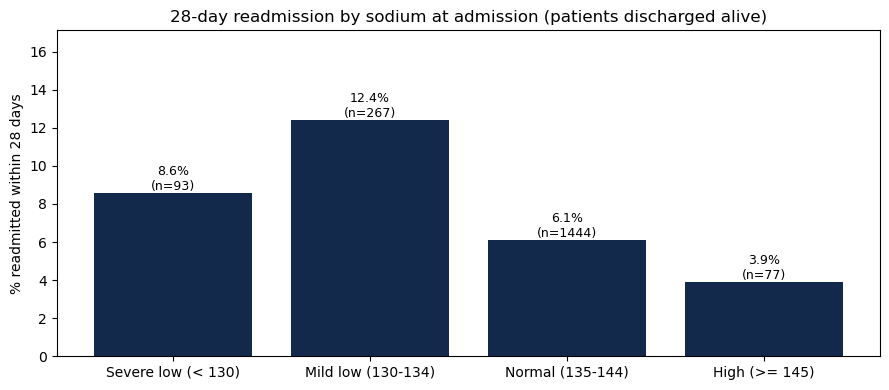

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

def rate_table(data, group, outcome):
    """Patients, events and event rate (%) of a 0/1 outcome for each group."""
    t = data.groupby(group, observed=True)[outcome].agg(patients="size", events="sum")
    t["rate_%"] = (t["events"] / t["patients"] * 100).round(1)
    return t
alive = df[(df["hospitalization_outcome"] == "Alive") & df["sodium"].notna()].copy()
alive["sodium_level"] = pd.cut(alive["sodium"], [0, 130, 135, 145, 200], right=False,
                               labels=["Severe low (< 130)", "Mild low (130-134)", "Normal (135-144)", "High (>= 145)"])
r28 = rate_table(alive, "sodium_level", "readmission_28d"); r6 = rate_table(alive, "sodium_level", "readmission_6m")
print("28-day readmission:"); print(r28); print("\n6-month readmission:"); print(r6)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(r28.index.astype(str), r28["rate_%"], color="#13294B")
for b, (r, n) in zip(bars, zip(r28["rate_%"], r28["patients"])):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{r}%\n(n={n})", ha="center", va="bottom", fontsize=9)
ax.set_title("28-day readmission by sodium at admission (patients discharged alive)")
ax.set_ylabel("% readmitted within 28 days")
ax.set_ylim(0, max(r28["rate_%"]) * 1.3 + 1)
plt.tight_layout()
plt.show()

### Key Insights
**How to read the chart:** Each bar is a sodium group, from lowest to highest. The bar height is the % of those patients who came back to hospital within 28 days. n = number of patients in the group.

* Low sodium raises early readmission: **12.4%** (mildly low, about double) and 8.6% (severely low) vs **6.1%** with normal sodium.
* The pattern holds over 6 months (48.3% vs 38.2%).

### Prescriptive Action to be taken
* **Sodium below 135 mmol/L** → recheck before discharge, review the water-tablet dose and fluid advice, and book a **check-up with a blood test within 7 days**.

## 21. Is low albumin (malnutrition/congestion) linked to death and longer stays?
### Reasoning
**Albumin** is the main protein in the blood, made by the liver. It falls with poor nutrition, long-term inflammation, and when the gut and liver are swollen with fluid (**congestion**). Low albumin can mark frail patients who recover slowly.

### Metrics Biomarkers and Features used
* **Blood albumin:** `albumin`, in grams per litre (g/L). Groups: below 30 very low, 30–34 low, 35 or more normal
* **Outcomes:** `death_6m`; **long stay** = `discharge_day` of 14 days or more

### Why used
Albumin is a routine blood test; death and long stays show how much it matters.

6-month death:
                 patients  events  rate_%
albumin_level                            
Very low (< 30)       177       6     3.4
Low (30-34)           471      19     4.0
Normal (>= 35)       1258      26     2.1

Stay of 14+ days:
                 patients  events  rate_%
albumin_level                            
Very low (< 30)       177      31    17.5
Low (30-34)           471      73    15.5
Normal (>= 35)       1258     151    12.0

Median stay (days): {'Very low (< 30)': 8.0, 'Low (30-34)': 8.0, 'Normal (>= 35)': 7.0}


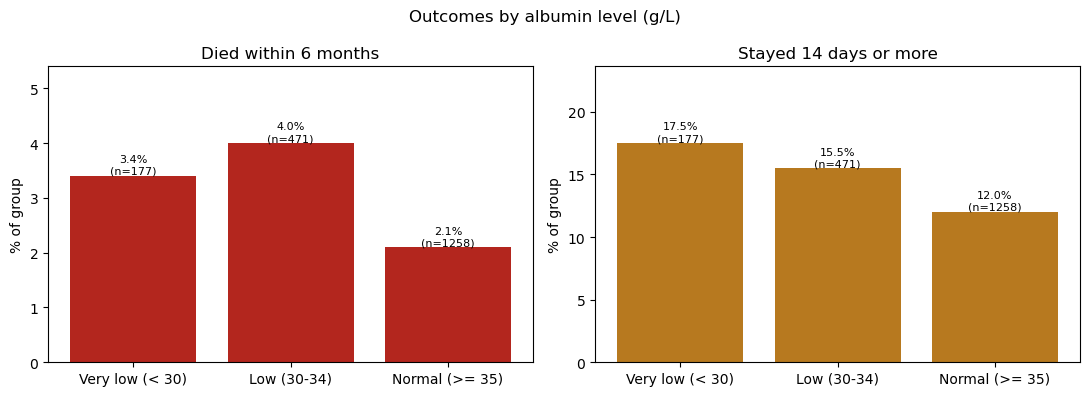

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

def rate_table(data, group, outcome):
    """Patients, events and event rate (%) of a 0/1 outcome for each group."""
    t = data.groupby(group, observed=True)[outcome].agg(patients="size", events="sum")
    t["rate_%"] = (t["events"] / t["patients"] * 100).round(1)
    return t
d = df[df["albumin"].notna()].copy()
d["albumin_level"] = pd.cut(d["albumin"], [0, 30, 35, 100], right=False, labels=["Very low (< 30)", "Low (30-34)", "Normal (>= 35)"])
d["long_stay"] = (d["discharge_day"] >= 14).astype(int)
death = rate_table(d, "albumin_level", "death_6m"); stay = rate_table(d, "albumin_level", "long_stay")
median_stay = d.groupby("albumin_level", observed=True)["discharge_day"].median()
print("6-month death:"); print(death); print("\nStay of 14+ days:"); print(stay); print("\nMedian stay (days):", median_stay.to_dict())

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, t, title, col in [(ax[0], death, "Died within 6 months", "#B3261E"), (ax[1], stay, "Stayed 14 days or more", "#B7791F")]:
    b = a.bar(t.index.astype(str), t["rate_%"], color=col)
    for bb, r, n in zip(b, t["rate_%"], t["patients"]):
        a.text(bb.get_x() + bb.get_width() / 2, r, f"{r}%\n(n={n})", ha="center", va="bottom", fontsize=8)
    a.set_title(title); a.set_ylabel("% of group"); a.set_ylim(0, t["rate_%"].max() * 1.35)
fig.suptitle("Outcomes by albumin level (g/L)")
plt.tight_layout()
plt.show()

### Key Insights
**How to read the chart:** Two charts with the same three albumin groups. Left: % who died within 6 months. Right: % who stayed in hospital 14 days or more. The label shows the % and number of patients (n). Taller bars in the low-albumin groups mean higher risk.

* Low albumin raises **6-month death** about 1.5–2×: 4.0% (low) and 3.4% (very low) vs 2.1% (normal).
* Long stays are more common: 17.5% and 15.5% vs 12.0%.

### Prescriptive Action to be taken
* **Albumin below 35 g/L** → dietitian review and nutrition support during the stay.
* Very low albumin with slow recovery → plan discharge early (home support, rehabilitation).

## 22. Which lab markers move together — do they form distinct biological "axes" of HF severity?
### Reasoning
Blood tests that always rise and fall together measure the same body system, so ordering all of them adds little. Tests that move independently each add new information. Finding these groups ("axes") shows which tests to combine in a risk check.

### Metrics Biomarkers and Features used
* **Kidney tests:** `glomerular_filtration_rate` (**estimated glomerular filtration rate, eGFR**: how well the kidneys filter blood; higher is better), `creatinine` and `urea` (waste products the kidneys remove; higher is worse), `uric_acid` (another waste product, raised by kidney problems and water tablets)
* **Blood and nutrition:** `hemoglobin` (**haemoglobin**, the oxygen-carrying protein in red blood cells), `platelet` (**platelets**, clotting cells), `albumin` and `total_protein` (blood proteins), `calcium`
* **Salt balance:** `sodium`, `chloride`
* **Immune cells:** `lymphocyte_count` (**lymphocytes**, fight infection and fall with stress), `neutrophil_ratio` (% of white cells that are **neutrophils**, which rise with stress and infection)

### Why used
These tests are done for almost every patient and cover the kidneys, blood, nutrition, salt balance and immune response. **Spearman correlation** is used: a number from −1 to +1 showing how strongly two tests move together (+1 = always rise together, −1 = one always rises as the other falls, 0 = unrelated).

                         eGFR (kidney filtering)  Urea  Creatinine  Uric acid  Haemoglobin  Platelets  Albumin  Total protein  Sodium  Chloride  Calcium  Lymphocytes  Neutrophil %
eGFR (kidney filtering)                     1.00 -0.67       -0.94      -0.52         0.33       0.01     0.17           0.05    0.17      0.04     0.04         0.15         -0.12
Urea                                       -0.67  1.00        0.69       0.57        -0.19      -0.06    -0.14          -0.07   -0.26     -0.12     0.00        -0.14          0.15
Creatinine                                 -0.94  0.69        1.00       0.59        -0.23      -0.02    -0.16          -0.07   -0.18     -0.03    -0.03        -0.11          0.09
Uric acid                                  -0.52  0.57        0.59       1.00        -0.00      -0.04    -0.02           0.04   -0.18     -0.19     0.11         0.01          0.03
Haemoglobin                                 0.33 -0.19       -0.23      -0.00         1.00       0.0

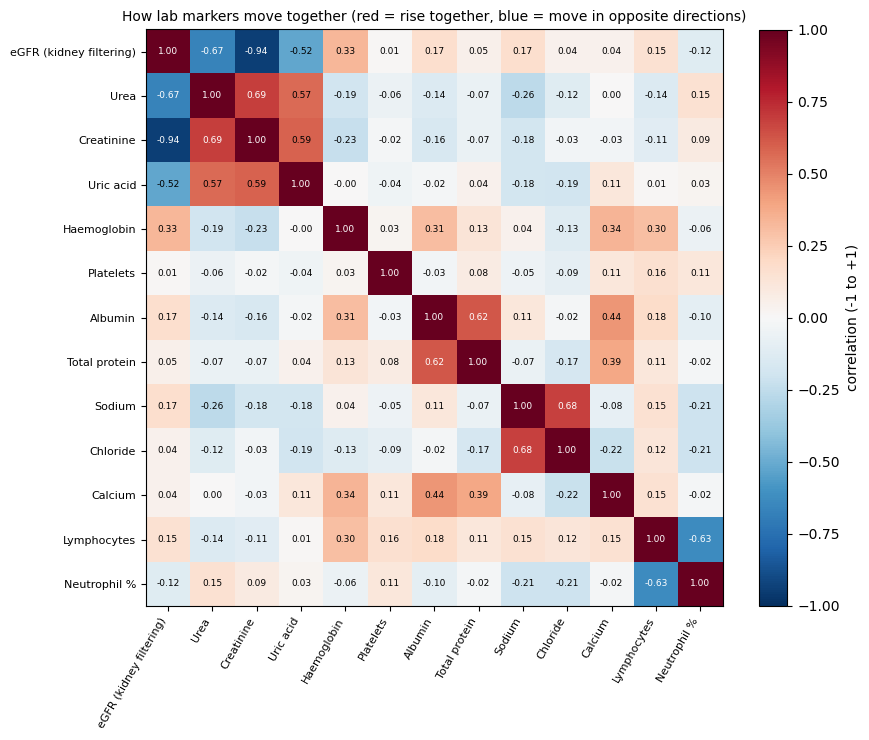

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)
# Routine lab markers (column name: readable name)
markers = {"glomerular_filtration_rate": "eGFR (kidney filtering)", "urea": "Urea", "creatinine": "Creatinine", "uric_acid": "Uric acid",
           "hemoglobin": "Haemoglobin", "platelet": "Platelets", "albumin": "Albumin", "total_protein": "Total protein",
           "sodium": "Sodium", "chloride": "Chloride", "calcium": "Calcium", "lymphocyte_count": "Lymphocytes", "neutrophil_ratio": "Neutrophil %"}
corr = df[list(markers)].rename(columns=markers).corr(method="spearman").round(2)
print(corr.to_string())

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=60, ha="right", fontsize=8)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=6.5, color="white" if abs(corr.iloc[i, j]) > 0.6 else "black")
plt.colorbar(im, fraction=0.04, label="correlation (-1 to +1)"); ax.set_title("How lab markers move together (red = rise together, blue = move in opposite directions)", fontsize=10)
plt.tight_layout()
plt.show()

### Key Insights
**How to read the chart:** This is a grid: every row and every column is a blood test. Each square shows how closely the two tests move together. **Dark red** = they rise and fall together; **dark blue** = when one goes up the other goes down; **white/pale** = no connection. The diagonal is always 1 (each test compared with itself). Look for blocks of strong colour: those are the "axes".

* **Kidney axis:** eGFR, creatinine, urea and uric acid move strongly together (eGFR–creatinine -0.94, eGFR–urea -0.67, creatinine–uric acid 0.59).
* **Nutrition/protein axis:** albumin, total protein and calcium (albumin–total protein 0.62, albumin–calcium 0.44).
* **Salt axis:** sodium and chloride (0.68).
* **Stress/immune axis:** lymphocytes fall as neutrophils rise (-0.63).
* Links **between** axes are weak (e.g. eGFR–albumin 0.17), so each axis adds separate information.

### Prescriptive Action to be taken
* For a quick risk check, use **one test from each axis** (e.g. eGFR + albumin + sodium + lymphocytes) instead of several kidney tests.
* Creatinine and eGFR carry the same information (correlation -0.94), so report eGFR only.

## 23. Which individual comorbidities matter most, and for which outcome?
### Reasoning
**Comorbidities** are other long-term illnesses a patient has alongside heart failure. Some may raise the risk of death, others of coming back to hospital. Knowing which is which tells the team where to focus.

### Metrics Biomarkers and Features used
* **Comorbidity flags** (1 = has the condition): `moderate_to_severe_chronic_kidney_disease` (**chronic kidney disease, CKD**: long-term kidney damage), `diabetes`, `chronic_obstructive_pulmonary_disease` (**COPD**: long-term lung disease such as emphysema), `cerebrovascular_disease` (previous **stroke**), `dementia`, `liver_disease`, `type2_respiratory_failure` (**type II respiratory failure**: the lungs cannot clear carbon dioxide, CO₂), `solid_tumor` (**cancer**)
* **Outcomes:** `death_6m`, `readmission_6m`

### Why used
"Times higher" = the event rate in patients **with** the condition divided by the rate in patients **without** it. 1 = no difference; 2 = twice as likely.

                            patients  death_6m_with_%  death_6m_without_%  readm_6m_with_%  readm_6m_without_%  death_times_higher  readm_times_higher
condition                                                                                                                                             
Dementia                         115              0.9                 3.0             50.4                37.8                0.30                1.33
COPD                             233              1.7                 3.0             38.2                38.5                0.57                0.99
Diabetes                         466              2.8                 2.9             45.7                36.3                0.97                1.26
Stroke                           150              4.0                 2.7             39.3                38.4                1.48                1.02
Solid tumour                      39              5.1                 2.8             35.9    

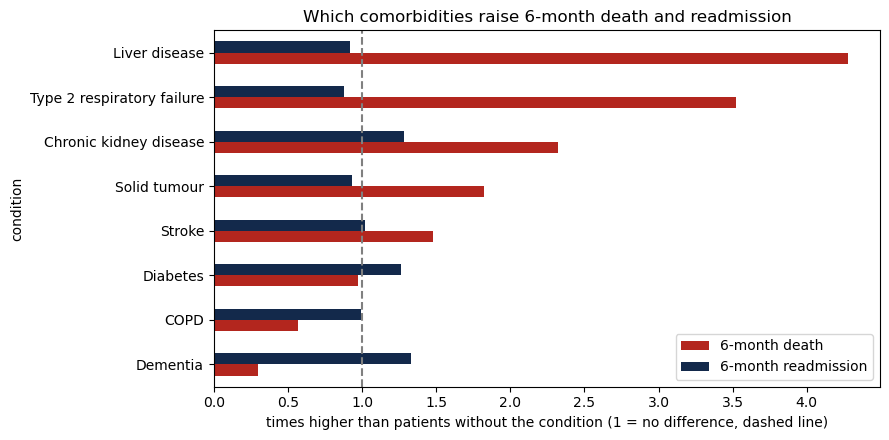

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

conditions = {"moderate_to_severe_chronic_kidney_disease": "Chronic kidney disease", "diabetes": "Diabetes",
              "chronic_obstructive_pulmonary_disease": "COPD", "cerebrovascular_disease": "Stroke", "dementia": "Dementia",
              "liver_disease": "Liver disease", "type2_respiratory_failure": "Type 2 respiratory failure", "solid_tumor": "Solid tumour"}
rows = []
for col, name in conditions.items():
    has, no = df[df[col] == 1], df[df[col] == 0]
    rows.append({"condition": name, "patients": len(has),
                 "death_6m_with_%": round(has["death_6m"].mean() * 100, 1), "death_6m_without_%": round(no["death_6m"].mean() * 100, 1),
                 "readm_6m_with_%": round(has["readmission_6m"].mean() * 100, 1), "readm_6m_without_%": round(no["readmission_6m"].mean() * 100, 1)})
t = pd.DataFrame(rows).set_index("condition")
t["death_times_higher"] = (t["death_6m_with_%"] / t["death_6m_without_%"]).round(2)
t["readm_times_higher"] = (t["readm_6m_with_%"] / t["readm_6m_without_%"]).round(2)
t = t.sort_values("death_times_higher")
print(t.to_string())

ax = t[["death_times_higher", "readm_times_higher"]].plot.barh(figsize=(9, 4.5), color=["#B3261E", "#13294B"])
ax.legend(["6-month death", "6-month readmission"], loc="lower right")
ax.axvline(1, color="grey", ls="--"); ax.set_xlabel("times higher than patients without the condition (1 = no difference, dashed line)")
ax.set_title("Which comorbidities raise 6-month death and readmission")
plt.tight_layout()
plt.show()

### Key Insights
**How to read the chart:** Each condition has two bars. Red = how many times more likely death within 6 months is for people with that condition; navy = the same for readmission. The dashed line at 1 means "no difference"; bars reaching past it mean higher risk, bars stopping short of it mean lower risk.

* **For death:** liver disease (4.28× more likely), type II respiratory failure (3.52×) and CKD (2.32×) matter most.
* **For readmission:** dementia (1.33×), CKD (1.28×) and diabetes (1.26×) matter most.
* **CKD** is the only condition that raises **both** death and readmission.

### Prescriptive Action to be taken
* **Liver disease, type II respiratory failure, CKD** → closer monitoring and an early conversation about the patient's wishes for care.
* **Dementia, diabetes** → involve carers in the discharge plan and give medication support to reduce readmission.

## 24. What happens to patients who discharge themselves against medical advice?
### Reasoning
Some patients leave hospital before the doctors think it is safe (**discharge against medical advice**), often because of cost or family reasons. Their outcomes show how dangerous this is.

### Metrics Biomarkers and Features used
* **How the stay ended:** `hospitalization_outcome`: Alive (regular discharge) or DischargeAgainstOrder (left against medical advice)
* **Outcomes:** `death_28d`, `death_6m`, `readmission_6m`
* **Severity:** `severe_hf` (Team05 flag: severe breathlessness and severe congestion/shock at admission)
* **Length of stay:** `discharge_day`

### Why used
Comparing with regular discharges shows the size of the risk; severity shows who leaves.

discharge       Regular discharge  Left against advice
patients                   1890.0                107.0
death_28d                     0.4                 18.7
death_6m                      1.4                 18.7
readmission_6m               39.4                 26.2
severe_hf                    17.8                 38.3
median_stay                   8.0                  6.0

Where the 28-day deaths came from: {'DischargeAgainstOrder': 20, 'Dead': 9, 'Alive': 8}


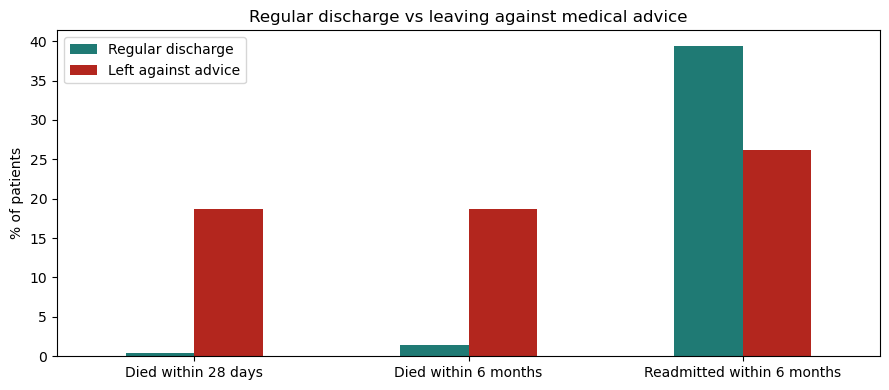

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)
out = df[df["hospitalization_outcome"].isin(["Alive", "DischargeAgainstOrder"])].copy()
out["discharge"] = out["hospitalization_outcome"].map({"Alive": "Regular discharge", "DischargeAgainstOrder": "Left against advice"})
table = out.groupby("discharge").agg(patients=("patient_id", "size"),
                                     death_28d=("death_28d", lambda s: round(s.mean() * 100, 1)),
                                     death_6m=("death_6m", lambda s: round(s.mean() * 100, 1)),
                                     readmission_6m=("readmission_6m", lambda s: round(s.mean() * 100, 1)),
                                     severe_hf=("severe_hf", lambda s: round(s.mean() * 100, 1)),
                                     median_stay=("discharge_day", "median"))
table = table.reindex(["Regular discharge", "Left against advice"])
share = df.loc[df["death_28d"] == 1, "hospitalization_outcome"].value_counts()
print(table.T); print("\nWhere the 28-day deaths came from:", share.to_dict())

ax = table[["death_28d", "death_6m", "readmission_6m"]].T.plot.bar(figsize=(9, 4), rot=0, color=["#1F7A74", "#B3261E"])
ax.set_xticklabels(["Died within 28 days", "Died within 6 months", "Readmitted within 6 months"]); ax.set_ylabel("% of patients")
ax.set_title("Regular discharge vs leaving against medical advice"); ax.legend(title=None)
plt.tight_layout()
plt.show()

### Key Insights
**How to read the chart:** Three pairs of bars. Teal = patients discharged normally; red = patients who left against advice. Compare the two colours in each pair: a much taller red bar means much higher risk for those who left.

* **18.7%** of patients who left against advice died within 28 days, vs **0.4%** after a regular discharge.
* They are a small group (107 patients) but account for **20 of all 37 deaths within 28 days**.
* They were sicker (38.3% severe HF vs 17.8%) and left earlier (median 6 vs 8 days).
* Their lower readmission (26.2%) reflects deaths, not better health.

### Prescriptive Action to be taken
* When a patient asks to leave: a **senior doctor conversation** to explain the risk, and help with the reason (cost, family).
* If they still leave: offer **home or palliative (comfort) care** support and a follow-up phone call within 48 hours.

## 25. Is length of stay linked to readmission — do short stays mean premature discharge?
### Reasoning
When beds are short, hospital stays get shorter. If short stays led to more readmissions, patients would be going home too early.

### Metrics Biomarkers and Features used
* **Length of stay (LOS):** `discharge_day`, number of days in hospital, grouped 1–4, 5–7, 8–10, 11–14, 15+
* **Outcomes:** `readmission_6m`, `readmission_28d`
* Only regular discharges: `hospitalization_outcome` = Alive

### Why used
Only patients who went home alive can be readmitted.

6-month readmission:
          patients  events  rate_%
stay                              
1-4 days       200      47    23.5
5-7            691     262    37.9
8-10           524     222    42.4
11-14          262     106    40.5
15+            213     108    50.7

28-day readmission:
          patients  events  rate_%
stay                              
1-4 days       200      11     5.5
5-7            691      47     6.8
8-10           524      35     6.7
11-14          262      26     9.9
15+            213      13     6.1


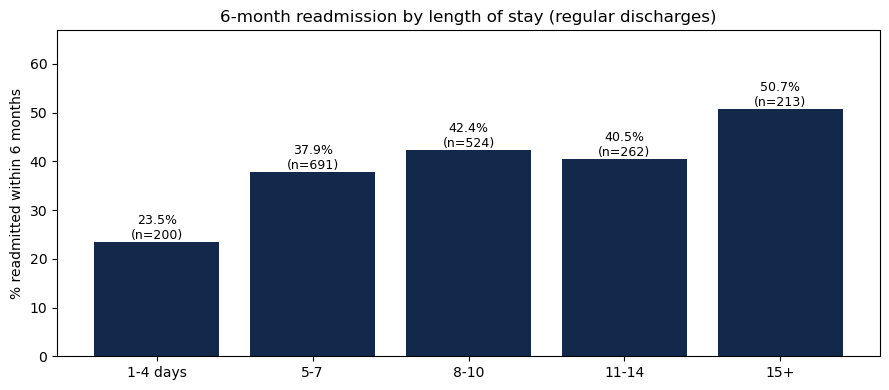

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

def rate_table(data, group, outcome):
    """Patients, events and event rate (%) of a 0/1 outcome for each group."""
    t = data.groupby(group, observed=True)[outcome].agg(patients="size", events="sum")
    t["rate_%"] = (t["events"] / t["patients"] * 100).round(1)
    return t

alive = df[df["hospitalization_outcome"] == "Alive"].copy()           # regular discharges only
alive["stay"] = pd.cut(alive["discharge_day"], [0, 4, 7, 10, 14, 500], labels=["1-4 days", "5-7", "8-10", "11-14", "15+"])
r6 = rate_table(alive, "stay", "readmission_6m"); r28 = rate_table(alive, "stay", "readmission_28d")
print("6-month readmission:"); print(r6); print("\n28-day readmission:"); print(r28)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(r6.index.astype(str), r6["rate_%"], color="#13294B")
for b, (r, n) in zip(bars, zip(r6["rate_%"], r6["patients"])):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{r}%\n(n={n})", ha="center", va="bottom", fontsize=9)
ax.set_title("6-month readmission by length of stay (regular discharges)")
ax.set_ylabel("% readmitted within 6 months")
ax.set_ylim(0, max(r6["rate_%"]) * 1.3 + 1)
plt.tight_layout()
plt.show()

### Key Insights
**How to read the chart:** Each bar is a length-of-stay group, from shortest to longest. The height is the % readmitted within 6 months; n = number of patients. If short stays were unsafe, the left-hand bars would be the tallest.

* Readmission **rises** with longer stays: **23.5%** (1–4 days) → **50.7%** (15+ days).
* Readmission within 28 days shows no clear pattern (5.5–9.9%).
* Short stays are **not** premature discharges; long stays mark more complex patients.

### Prescriptive Action to be taken
* Do not keep patients longer just to prevent readmission.
* Treat a **stay of 11+ days as a readmission warning sign** → a stronger discharge package (medicine review, early follow-up).

## 26. Does hyponatraemia plus the need for IV diuretics identify "hard-to-decongest" patients who bounce back within 28 days?
### Reasoning
**Decongestion** means removing the extra fluid heart failure causes, mainly with **diuretics** (water tablets or injections). Patients who need **intravenous (IV)** diuretics (given into a vein) and still have **hyponatraemia** (low blood sodium) are often hard to clear of fluid and may go home still overloaded.

### Metrics Biomarkers and Features used
* **Low sodium:** `sodium` below 135 mmol/L
* **IV diuretic:** `drug_Furosemide_Injection` = 1 (furosemide given by injection)
* **Outcomes:** `readmission_28d`, `readmission_6m`
* Only patients who went home alive: `hospitalization_outcome` = Alive

### Why used
Readmission within 28 days is the outcome most linked to going home with fluid still on board.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

def rate_table(data, group, outcome):
    """Patients, events and event rate (%) of a 0/1 outcome for each group."""
    t = data.groupby(group, observed=True)[outcome].agg(patients="size", events="sum")
    t["rate_%"] = (t["events"] / t["patients"] * 100).round(1)
    return t
alive = df[(df["hospitalization_outcome"] == "Alive") & df["sodium"].notna()].copy()
low_na = alive["sodium"] < 135
iv = alive["drug_Furosemide_Injection"] == 1
alive["group"] = np.select([~low_na & ~iv, ~low_na & iv, low_na & ~iv, low_na & iv],
                           ["1 Normal sodium, no IV diuretic", "2 Normal sodium + IV diuretic", "3 Low sodium, no IV diuretic", "4 Low sodium + IV diuretic"], "")
r28 = rate_table(alive, "group", "readmission_28d"); r6 = rate_table(alive, "group", "readmission_6m")
print("Share given IV furosemide:", round(iv.mean() * 100, 1), "%")
print("28-day readmission:"); print(r28); print("\n6-month readmission:"); print(r6)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(r28.index.astype(str), r28["rate_%"], color="#13294B")
for b, (r, n) in zip(bars, zip(r28["rate_%"], r28["patients"])):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{r}%\n(n={n})", ha="center", va="bottom", fontsize=9)
ax.set_title("28-day readmission: low sodium x IV diuretic")
ax.set_ylabel("% readmitted within 28 days")
ax.set_ylim(0, max(r28["rate_%"]) * 1.3 + 1)
ax.set_xticks(range(len(r28))); ax.set_xticklabels([s[2:].replace(", ", ",\n").replace(" + ", "\n+ ") for s in r28.index], fontsize=8)
plt.tight_layout()
plt.show()

### Key Insights
**How to read the chart:** Each bar is one combination of sodium level and IV diuretic. The height is the % readmitted within 28 days; n = number of patients. The right-most bar is the "hard-to-decongest" group.

* **Low sodium + IV diuretic:** **11.8%** readmitted within 28 days, about twice the 5.2–6.1% of patients with normal sodium.
* IV diuretics are given to almost everyone (86% of patients), so **low sodium is the useful warning sign** within this group.

### Prescriptive Action to be taken
* Low sodium while on IV diuretics → check for remaining fluid before discharge (daily weight, leg swelling) and **follow up within 7 days** with a sodium and kidney blood test.

## 27. Is low blood pressure at admission a warning sign for death and readmission?
### Reasoning
In heart failure, a low **systolic blood pressure (SBP)**, the top blood-pressure number, can mean the heart is too weak to push blood around the body. It also limits which heart medicines can be given.

### Metrics Biomarkers and Features used
* **Systolic blood pressure (SBP):** `sbp`, in millimetres of mercury (mmHg). Groups: below 100 low, 100–139 normal, 140 or more high
* **Outcomes:** `death_6m`, `readmission_6m`

### Why used
Blood pressure is measured for every patient on arrival, so it is a free and instant warning sign.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

def rate_table(data, group, outcome):
    """Patients, events and event rate (%) of a 0/1 outcome for each group."""
    t = data.groupby(group, observed=True)[outcome].agg(patients="size", events="sum")
    t["rate_%"] = (t["events"] / t["patients"] * 100).round(1)
    return t
d = df[df["sbp"].notna()].copy()
d["bp_level"] = pd.cut(d["sbp"], [0, 100, 140, 400], right=False, labels=["Low (< 100)", "Normal (100-139)", "High (>= 140)"])
death = rate_table(d, "bp_level", "death_6m"); readm = rate_table(d, "bp_level", "readmission_6m")
print("6-month death:"); print(death); print("\n6-month readmission:"); print(readm)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, t, title, col in [(ax[0], death, "Died within 6 months", "#B3261E"), (ax[1], readm, "Readmitted within 6 months", "#13294B")]:
    b = a.bar(t.index.astype(str), t["rate_%"], color=col)
    for bb, r, n in zip(b, t["rate_%"], t["patients"]):
        a.text(bb.get_x() + bb.get_width() / 2, r, f"{r}%\n(n={n})", ha="center", va="bottom", fontsize=8)
    a.set_title(title); a.set_ylabel("% of group"); a.set_ylim(0, t["rate_%"].max() * 1.35); a.tick_params(axis="x", labelsize=8)
    a.set_xticks(range(len(t))); a.set_xticklabels([str(x).replace(" (", "\n(") for x in t.index], fontsize=8)
fig.suptitle("Outcomes by systolic blood pressure at admission (sbp, mmHg)")
plt.tight_layout()
plt.show()

### Key Insights
**How to read the chart:** Two charts with the same three blood-pressure groups (low on the left). Left: % who died within 6 months. Right: % readmitted within 6 months. The label shows the % and the number of patients (n).

* Patients with **low blood pressure** had higher death (4.6% vs 2.6% normal) and higher readmission (**49.0%** vs 39.6%).
* High blood pressure was **not** worse (death 2.6%, readmission 34.8%): in heart failure, a strong pressure usually means a stronger heart.
* The low-pressure group is small (153 patients).

### Prescriptive Action to be taken
* **SBP below 100 mmHg** → senior review, careful fluid and medicine adjustment, and a follow-up visit within 7 days.
* Start heart-failure medicines at low doses in these patients and increase slowly.

## 28. Does a fast heart rate at admission signal higher risk?
### Reasoning
A fast heart rate (**tachycardia**, above 100 beats per minute) can mean the heart is struggling or beating irregularly. We check whether it predicts early death or readmission.

### Metrics Biomarkers and Features used
* **Heart rate:** `pulse`, beats per minute (bpm). Groups: below 60 slow, 60–100 normal, above 100 fast
* **Outcomes:** `death_28d`, `readmission_6m`

### Why used
Heart rate is measured on arrival for every patient.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

def rate_table(data, group, outcome):
    """Patients, events and event rate (%) of a 0/1 outcome for each group."""
    t = data.groupby(group, observed=True)[outcome].agg(patients="size", events="sum")
    t["rate_%"] = (t["events"] / t["patients"] * 100).round(1)
    return t
d = df[df["pulse"].notna()].copy()
d["heart_rate"] = pd.cut(d["pulse"], [0, 60, 101, 400], right=False, labels=["Slow (< 60)", "Normal (60-100)", "Fast (> 100)"])
death = rate_table(d, "heart_rate", "death_28d"); readm = rate_table(d, "heart_rate", "readmission_6m")
print("28-day death:"); print(death); print("\n6-month readmission:"); print(readm)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, t, title, col in [(ax[0], death, "Died within 28 days", "#B3261E"), (ax[1], readm, "Readmitted within 6 months", "#13294B")]:
    b = a.bar(t.index.astype(str), t["rate_%"], color=col)
    for bb, r, n in zip(b, t["rate_%"], t["patients"]):
        a.text(bb.get_x() + bb.get_width() / 2, r, f"{r}%\n(n={n})", ha="center", va="bottom", fontsize=8)
    a.set_title(title); a.set_ylabel("% of group"); a.set_ylim(0, t["rate_%"].max() * 1.35); a.tick_params(axis="x", labelsize=8)
    a.set_xticks(range(len(t))); a.set_xticklabels([str(x).replace(" (", "\n(") for x in t.index], fontsize=8)
fig.suptitle("Outcomes by heart rate at admission (pulse, beats per minute)")
plt.tight_layout()
plt.show()

### Key Insights
**How to read the chart:** Two charts with the same three heart-rate groups. Left: % who died within 28 days. Right: % readmitted within 6 months. The label shows the % and number of patients (n). Similar bar heights mean heart rate does not change risk much.

* A fast heart rate was only slightly linked to early death (2.4% vs 1.7% with a normal rate).
* It was **not** linked to readmission (35.3% vs 39.6%).
* **Heart rate alone is a weak warning sign** in this group.

### Prescriptive Action to be taken
* Do not use heart rate alone to decide follow-up intensity.
* A fast rate should still prompt a heart-rhythm check (**electrocardiogram, ECG**), because an irregular rhythm needs its own treatment.

## 29. Do emergency admissions have worse outcomes than planned admissions?
### Reasoning
Patients admitted as an **emergency** usually arrive sicker than those with a **planned (non-emergency)** admission. We check whether this shows in their outcomes and hospital stay.

### Metrics Biomarkers and Features used
* **Admission route:** `admission_type` (Emergency / NonEmergency)
* **Outcomes:** `death_28d`, `readmission_28d`, `readmission_6m`
* **Severity:** `severe_hf`; **length of stay:** `discharge_day`

### Why used
Admission route is known on arrival and helps plan beds and follow-up.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)
table = df.groupby("admission_type").agg(patients=("patient_id", "size"),
                                        death_28d=("death_28d", lambda s: round(s.mean() * 100, 1)),
                                        readmission_28d=("readmission_28d", lambda s: round(s.mean() * 100, 1)),
                                        readmission_6m=("readmission_6m", lambda s: round(s.mean() * 100, 1)),
                                        severe_hf=("severe_hf", lambda s: round(s.mean() * 100, 1)),
                                        median_stay=("discharge_day", "median"))
print(table.T)

ax = table[["death_28d", "readmission_28d", "readmission_6m", "severe_hf"]].T.plot.bar(figsize=(9, 4), rot=0, color=["#B3261E", "#1F7A74"])
ax.set_xticklabels(["Died within 28 days", "Readmitted within 28 days", "Readmitted within 6 months", "Severe HF at admission"], fontsize=8)
ax.set_ylabel("% of patients"); ax.set_title("Emergency vs planned (non-emergency) admissions"); ax.legend(title=None)
plt.tight_layout()
plt.show()

### Key Insights
**How to read the chart:** Four pairs of bars. Red = emergency admissions, teal = planned admissions. Compare the two colours within each pair; the last pair shows how many were severely ill on arrival.

* Emergency patients were more often severely ill (21.8% vs 16.9% `severe_hf`).
* They had slightly higher early death (2.1% vs 1.6%) and 28-day readmission (7.6% vs 6.4%).
* Over 6 months, readmission was the same (38.4% vs 38.6%), and hospital stays were equal (median 8 days).

### Prescriptive Action to be taken
* Give emergency patients an **early check within 7–14 days** of discharge, the period when their extra risk shows.
* After that, follow-up can be the same for both routes.

## 30. Does high uric acid predict death or readmission?
### Reasoning
**Uric acid** is a waste product removed by the kidneys. It rises when the kidneys struggle and with strong diuretic (water tablet) use, and very high levels cause **gout** (painful joint swelling). It may be a simple marker of a stressed heart–kidney system.

### Metrics Biomarkers and Features used
* **Blood uric acid:** `uric_acid`, micromoles per litre (µmol/L). "High" = above 420 for men and 360 for women (`gender`)
* **Kidney function:** `glomerular_filtration_rate` (**eGFR**, higher = better filtering)
* **Outcomes:** `death_6m`, `readmission_6m`

### Why used
Uric acid is a cheap routine test; comparing kidney function shows why it rises.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Team05_PyCraft_Cleaned_data/wide_merged_table.csv")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)

def rate_table(data, group, outcome):
    """Patients, events and event rate (%) of a 0/1 outcome for each group."""
    t = data.groupby(group, observed=True)[outcome].agg(patients="size", events="sum")
    t["rate_%"] = (t["events"] / t["patients"] * 100).round(1)
    return t
d = df[df["uric_acid"].notna()].copy()
high_cut = np.where(d["gender"] == "Male", 420, 360)       # umol/L: common upper limits for men and women
d["uric_level"] = np.where(d["uric_acid"] > high_cut, "High uric acid", "Normal uric acid")
death = rate_table(d, "uric_level", "death_6m"); readm = rate_table(d, "uric_level", "readmission_6m")
kidney = d.groupby("uric_level")["glomerular_filtration_rate"].median().round(0)
print("6-month death:"); print(death); print("\n6-month readmission:"); print(readm); print("\nMedian eGFR:", kidney.to_dict())

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, t, title, col in [(ax[0], death, "Died within 6 months", "#B3261E"), (ax[1], readm, "Readmitted within 6 months", "#13294B")]:
    b = a.bar(t.index.astype(str), t["rate_%"], color=col)
    for bb, r, n in zip(b, t["rate_%"], t["patients"]):
        a.text(bb.get_x() + bb.get_width() / 2, r, f"{r}%\n(n={n})", ha="center", va="bottom", fontsize=8)
    a.set_title(title); a.set_ylabel("% of group"); a.set_ylim(0, t["rate_%"].max() * 1.35); a.tick_params(axis="x", labelsize=8)
    a.set_xticks(range(len(t))); a.set_xticklabels([str(x).replace(" (", "\n(") for x in t.index], fontsize=8)
fig.suptitle("Outcomes by uric acid level (uric_acid)")
plt.tight_layout()
plt.show()

### Key Insights
**How to read the chart:** Two charts, each with two bars (high vs normal uric acid). Left: % who died within 6 months. Right: % readmitted within 6 months. The label shows the % and number of patients (n).

* **68% of patients** have high uric acid.
* They were readmitted more often (**40.8%** vs 34.1%) and died slightly more often (3.1% vs 2.2%).
* Their kidneys work less well (median eGFR 54 vs 89), so uric acid largely reflects kidney strain.

### Prescriptive Action to be taken
* High uric acid → check kidney function and review diuretic doses before discharge.
* Treat gout attacks without anti-inflammatory painkillers (**NSAIDs**, e.g. ibuprofen), which worsen heart failure and kidneys.